In [ ]:
import os
import netCDF4 as nc
import pandas as pd

file_path = '/net/fs06/d3/rzhuang/TROPOMI_US/data/TROPOMI_2019-2024'

files = [os.path.join(file_path, item) for item in os.listdir(file_path) if item.endswith('.nc')]
broken_files = []
i=0

for file in files:
    
    try:
        with nc.Dataset(file) as ds:
            i=i+1
            # lats = ds['PRODUCT/latitude'][:]
            # lons = ds['PRODUCT/longitude'][:]
            # no2 = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:]
            # wind_u = ds['PRODUCT/SUPPORT_DATA/INPUT_DATA/eastward_wind'][:]
            # wind_v = ds['PRODUCT/SUPPORT_DATA/INPUT_DATA/northward_wind'][:]
            # utc_time = ds['PRODUCT/time_utc'][:]
    except Exception as e:
        print(f"{i}, Error with file {file}: {e}")
        broken_files.append(file)

print("Broken files:", broken_files)

In [10]:
prod = f.groups['PRODUCT']
geo  = prod.groups['SUPPORT_DATA'].groups['GEOLOCATIONS']
geo.variables['satellite_altitude'][0].shape

(2905,)

In [1]:
from netCDF4 import Dataset
f = Dataset('/net/fs06/d3/rzhuang/TROPOMI_world/data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____20180501T014222_20180501T032352_02833_03_020400_20221208T153328.nc')
# tropospheric NO2
print(f.groups['PRODUCT'].variables)
print(f.groups['PRODUCT'].groups['SUPPORT_DATA'].groups['GEOLOCATIONS'].variables)
tropos = f.groups['PRODUCT'].variables['nitrogendioxide_tropospheric_column']

# sensor geometry
geo = f.groups['PRODUCT'].groups['SUPPORT_DATA'].groups['GEOLOCATIONS']
sza = geo.variables['solar_zenith_angle']
vza = geo.variables['viewing_zenith_angle']

{'scanline': <class 'netCDF4.Variable'>
int32 scanline(scanline)
    units: 1
    axis: Y
    long_name: along-track dimension index
    comment: This coordinate variable defines the indices along track; index starts at 0
    _FillValue: -2147483647
path = /PRODUCT
unlimited dimensions: 
current shape = (2905,)
filling on, 'ground_pixel': <class 'netCDF4.Variable'>
int32 ground_pixel(ground_pixel)
    units: 1
    axis: X
    long_name: across-track dimension index
    comment: This coordinate variable defines the indices across track, from west to east; index starts at 0
    _FillValue: -2147483647
path = /PRODUCT
unlimited dimensions: 
current shape = (450,)
filling on, 'time': <class 'netCDF4.Variable'>
int32 time(time)
    units: seconds since 2010-01-01 00:00:00
    standard_name: time
    axis: T
    long_name: reference time for the measurements
    comment: The time in this variable corresponds to the time in the time_reference global attribute
    _FillValue: -2147483647
path 

In [2]:
f['PRODUCT/SUPPORT_DATA/INPUT_DATA/surface_albedo_nitrogendioxide_window'][:]

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, 0.0533515140414238, 0.07142923772335052, ...,
          0.9344245791435242, 0.8793241381645203, 0.9355306625366211],
         [--, 0.056947965174913406, 0.08429290354251862, ...,
          0.936224102973938, 0.8933343887329102, 0.9262168407440186],
         [--, 0.06081037595868111, 0.1511043906211853, ...,
          0.8859028220176697, 0.8720731139183044, 0.9326216578483582]]],
  mask=[[[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True, False, False, ..., False, False, False],
         [ True, False, False, ..., False, False, False],
         [ True, False, False, ..., False, False, False]]],
  fill_value=9.96921e+36,
  dtype=float32)

In [3]:
f['PRODUCT/SUPPORT_DATA/INPUT_DATA/surface_albedo'][:]

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, 0.009082760661840439, 0.038760650902986526, ...,
          0.8841189742088318, 0.8767181038856506, 0.8051996827125549],
         [--, 0.012102581560611725, 0.056592587381601334, ...,
          0.8076196908950806, 0.809004545211792, 0.802284836769104],
         [--, 0.018027089536190033, 0.13399457931518555, ...,
          0.9123921990394592, 0.8887584805488586, 0.8850948214530945]]],
  mask=[[[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True, False, False, ..., False, False, False],
         [ True, False, False, ..., False, False, False],
         [ True, False, False, ..., False, False, False]]],
  fill_value=9.96921e+36,
  dtype=float32)

In [21]:
import numpy as np
np.sum(f.groups['PRODUCT'].variables['qa_value'][:][0]>0.75)

np.int64(511715)

In [16]:
f.groups['PRODUCT']\
              .groups['SUPPORT_DATA']\
              .groups['GEOLOCATIONS']\
              .variables['geolocation_flags']

<class 'netCDF4.Variable'>
uint8 geolocation_flags(time, scanline, ground_pixel)
    _FillValue: 255
    coordinates: /PRODUCT/longitude /PRODUCT/latitude
    flag_masks: [  0   1   2   4   8  16  32 128]
    flag_meanings: no_error solar_eclipse sun_glint_possible descending night geo_boundary_crossing spacecraft_manoeuvre geolocation_error
    flag_values: [  0   1   2   4   8  16  32 128]
    long_name: geolocation flags
    max_val: 254
    min_val: 0
    units: 1
path = /PRODUCT/SUPPORT_DATA/GEOLOCATIONS
unlimited dimensions: 
current shape = (1, 2905, 450)
filling on

In [ ]:
import os
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree


def plant_valid(plant_lat, plant_lon, valid_ratio=0.5):
    global plant_valid_count
    plant_valid_count += 1

    if not (min_lat <= plant_lat <= max_lat and min_lon <= plant_lon <= max_lon):
        return False
    plant_rad = np.radians([plant_lat, plant_lon]).reshape(1, -1)
    indices = tree.query_radius(plant_rad, r=radius_rad)[0]
    if len(indices) == 0:
        return False
    print(f"plant_valid called {plant_valid_count} times")
    return (np.sum(valid_no2[indices]) / len(indices)) >= valid_ratio

# Global counter for plant_valid calls
plant_valid_count = 0

# --- Load TROPOMI data ---
file_path = '../data/TROPOMI_2018_data'
emissions_path = '../data/coco2_ps_catalogue_v2.0.csv'
emissions = pd.read_csv(emissions_path)
# Filter emissions data for the specified date
files = [os.path.join(file_path, item) for item in os.listdir(file_path) if item[-2:]=='nc']

for file in files :
    with nc.Dataset(file) as ds:
        lats = ds['PRODUCT/latitude'][:]
        lons = ds['PRODUCT/longitude'][:]
        no2 = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:]
        wind_u = ds['PRODUCT/SUPPORT_DATA/INPUT_DATA/eastward_wind'][:]
        wind_v = ds['PRODUCT/SUPPORT_DATA/INPUT_DATA/northward_wind'][:]
        utc_time = ds['PRODUCT/time_utc'][:]

    # Global bounds
    min_lat, max_lat = np.nanmin(lats), np.nanmax(lats)
    min_lon, max_lon = np.nanmin(lons), np.nanmax(lons)

    # Flatten arrays and convert to radians for BallTree
    lats_flat = lats.flatten()
    lons_flat = lons.flatten()
    points_rad = np.radians(np.column_stack((lats_flat, lons_flat)))
    tree = BallTree(points_rad, metric='haversine')
    radius_rad = 50 / 6371  # 50 km in radians

    # Prepare valid pixel mask from masked array no2.
    if np.ma.is_masked(no2):
        valid_no2 = (~no2.mask).flatten()
    else:
        valid_no2 = np.isfinite(no2.flatten())

    # Evaluate each power plant and record result.
    emissions['tropomi_valid'] = [
        plant_valid(lat, lon) for lat, lon in zip(emissions['latitude'], emissions['longitude'])
    ]

    result_df = emissions[['power_plant', 'tropomi_valid']]
    print(result_df)
    print("plant_valid called:", plant_valid_count, "times")

In [6]:
import numpy as np
import pandas as pd
import xarray as xr

# Configure file paths
META_CSV  = "/net/fs06/d3/rzhuang/TROPOMI_world/data/valid_tropomi_emissions_new_dropna_wind.csv"
GRIB_FILE = "/net/fs06/d3/rzhuang/TROPOMI_world/data/era5/vertical_velocity.grib"

def main():
    # Load and round plume timestamps to the nearest hour
    df = pd.read_csv(META_CSV)
    df['iso_hour'] = (
        pd.to_datetime(df['utc_time'], utc=True)
          .dt.round('H')
          .dt.tz_localize(None)
    )
    unique_plume_times = np.unique(df['iso_hour'].values)
    print("Plume times range:", unique_plume_times.min(), "to", unique_plume_times.max())

    # Open the GRIB file and extract its times
    ds = xr.open_dataset(GRIB_FILE, engine='cfgrib', decode_timedelta=False)
    time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
    file_times = pd.to_datetime(ds[time_dim].values).tz_localize(None)
    print("GRIB file times range:", file_times.min(), "to", file_times.max())

    # Compute mismatches
    plume_not_in = np.setdiff1d(unique_plume_times, file_times.values)
    print(f"\nPlume times missing in GRIB file ({len(plume_not_in)}):")
    print(plume_not_in[:20])

    file_not_in = np.setdiff1d(file_times.values, unique_plume_times)
    print(f"\nGRIB file times not found in plume list ({len(file_not_in)}):")
    print(file_not_in[:20])

if __name__ == "__main__":
    main()

/tmp/ipykernel_191113/234302154.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .dt.round('H')
Ignoring index file '/net/fs06/d3/rzhuang/TROPOMI_world/data/era5/vertical_velocity.grib.5b7b6.idx' incompatible with GRIB file


Plume times range: 2018-05-01T01:00:00.000000000 to 2018-12-31T23:00:00.000000000
GRIB file times range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00

Plume times missing in GRIB file (0):
[]

GRIB file times not found in plume list (3843):
['2018-01-01T00:00:00.000000000' '2018-01-01T01:00:00.000000000'
 '2018-01-01T02:00:00.000000000' '2018-01-01T03:00:00.000000000'
 '2018-01-01T04:00:00.000000000' '2018-01-01T05:00:00.000000000'
 '2018-01-01T06:00:00.000000000' '2018-01-01T07:00:00.000000000'
 '2018-01-01T08:00:00.000000000' '2018-01-01T09:00:00.000000000'
 '2018-01-01T10:00:00.000000000' '2018-01-01T11:00:00.000000000'
 '2018-01-01T12:00:00.000000000' '2018-01-01T13:00:00.000000000'
 '2018-01-01T14:00:00.000000000' '2018-01-01T15:00:00.000000000'
 '2018-01-01T16:00:00.000000000' '2018-01-01T17:00:00.000000000'
 '2018-01-01T18:00:00.000000000' '2018-01-01T19:00:00.000000000']


/tmp/ipykernel_3086272/1844636669.py:177: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  emission_df = pd.read_csv('../data/valid_tropomi_emissions_6000.csv')


Plant Latitude: 4.05
Plant Longitude: 9.7
Global Bounds: lat(-83.97555541992188 to 89.96693420410156), lon(-179.99969482421875 to 179.99984741210938)
Valid area within 50 km radius: 7753.50 km²
Valid ratio: 1.00
Circle area (π*50²): 7853.98 km²
Valid points count: 116
Total points count: 116


/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


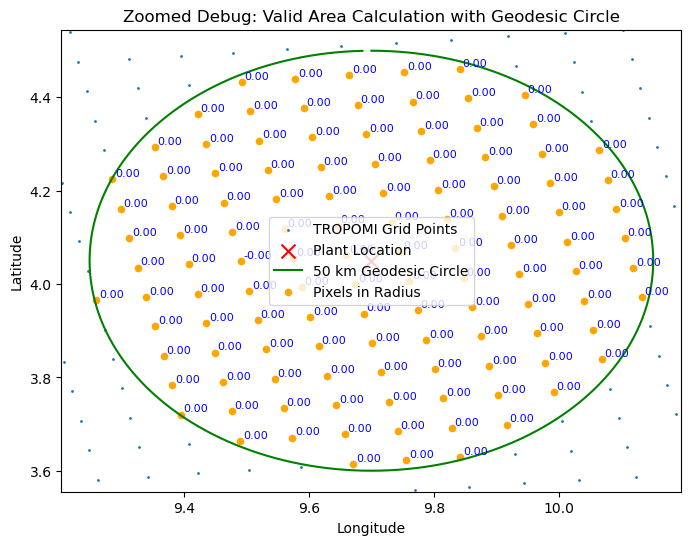

In [4]:
import numpy as np
import math
import netCDF4 as nc
import pandas as pd
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt
plt.rcdefaults()

def create_geodesic_circle(plant_lat, plant_lon, radius_km, n_points=100):
    """
    Return arrays of longitude and latitude (in degrees) for a geodesic circle
    of 'radius_km' around (plant_lat, plant_lon).
    """
    # Convert center to radians
    lat0 = math.radians(plant_lat)
    lon0 = math.radians(plant_lon)
    # Earth radius ~ 6371 km
    R = 6371.0
    # Angular distance
    d = radius_km / R
    
    circle_lats = []
    circle_lons = []
    
    for i in range(n_points):
        # Bearing from 0 to 2*pi
        bearing = 2 * math.pi * i / n_points
        
        # Spherical law-of-cosines / haversine style approach
        lat = math.asin(
            math.sin(lat0) * math.cos(d) +
            math.cos(lat0) * math.sin(d) * math.cos(bearing)
        )
        lon = lon0 + math.atan2(
            math.sin(bearing) * math.sin(d) * math.cos(lat0),
            math.cos(d) - math.sin(lat0) * math.sin(lat)
        )
        
        circle_lats.append(math.degrees(lat))
        circle_lons.append(math.degrees(lon))
    
    return np.array(circle_lons), np.array(circle_lats)

def calculate_pixel_areas(plant_lat, plant_lon, min_lat, max_lat, min_lon, max_lon, 
                          tree, valid_no2, radius_rad, lats, lons):
    """Calculate area of valid TROPOMI pixels within radius."""
    if not (min_lat <= plant_lat <= max_lat and min_lon <= plant_lon <= max_lon):
        return 0, 0
    
    plant_rad = np.radians([plant_lat, plant_lon]).reshape(1, -1)
    indices = tree.query_radius(plant_rad, r=radius_rad)[0]
    if len(indices) == 0:
        return 0, 0
    
    valid_indices = indices[valid_no2[indices]]
    total_indices = len(indices)
    valid_count = len(valid_indices)
    if total_indices == 0:
        return 0, 0

    # Build mask for calculate_areas
    mask = np.zeros(lats.shape, dtype=bool)
    mask.flat[valid_indices] = True

    def calculate_areas(mask, lat_2d, lon_2d):
        plume_indices = np.where(mask)
        pixel_areas = []
        for y, x in zip(*plume_indices):
            area_estimates = []
            if x+1 < lon_2d.shape[1]:
                dlon = abs(lon_2d[y, x+1] - lon_2d[y, x])
                if y+1 < lat_2d.shape[0]:
                    dlat = abs(lat_2d[y+1, x] - lat_2d[y, x])
                    lat_km = dlat * 111.14
                    lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                    area_estimates.append(lat_km * lon_km)
                if y-1 >= 0:
                    dlat = abs(lat_2d[y-1, x] - lat_2d[y, x])
                    lat_km = dlat * 111.14
                    lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                    area_estimates.append(lat_km * lon_km)
            if x-1 >= 0:
                dlon = abs(lon_2d[y, x-1] - lon_2d[y, x])
                if y+1 < lat_2d.shape[0]:
                    dlat = abs(lat_2d[y+1, x] - lat_2d[y, x])
                    lat_km = dlat * 111.14
                    lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                    area_estimates.append(lat_km * lon_km)
                if y-1 >= 0:
                    dlat = abs(lat_2d[y-1, x] - lat_2d[y, x])
                    lat_km = dlat * 111.14
                    lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                    area_estimates.append(lat_km * lon_km)
            if area_estimates:
                pixel_areas.append(np.mean(area_estimates))
            else:
                pixel_areas.append(25.0)
        return sum(pixel_areas) if pixel_areas else 0.0

    valid_area = calculate_areas(mask, lats, lons)
    return valid_area, valid_count / total_indices

def debug_plant_valid(emission, lats, lons, no2, tree, valid_no2, radius_rad):
    plant_lat = emission['latitude']
    plant_lon = emission['longitude']
    print("Plant Latitude:", plant_lat)
    print("Plant Longitude:", plant_lon)
    
    min_lat, max_lat = np.nanmin(lats), np.nanmax(lats)
    min_lon, max_lon = np.nanmin(lons), np.nanmax(lons)
    
    print("Global Bounds: lat({} to {}), lon({} to {})".format(min_lat, max_lat, min_lon, max_lon))
    
    valid_area, valid_ratio = calculate_pixel_areas(
        plant_lat, plant_lon, min_lat, max_lat, min_lon, max_lon,
        tree, valid_no2, radius_rad, lats, lons
    )
    
    print(f"Valid area within 50 km radius: {valid_area:.2f} km²")
    print(f"Valid ratio: {valid_ratio:.2f}")
    print(f"Circle area (π*50²): {np.pi*(50**2):.2f} km²")
    
    plant_rad = np.radians([plant_lat, plant_lon]).reshape(1, -1)
    indices = tree.query_radius(plant_rad, r=radius_rad)[0]
    if len(indices) == 0:
        print("No nearby points found.")
        return
    
    valid_count = np.sum(valid_no2[indices])
    total_points = len(indices)
    ratio = valid_count / total_points
    print(f"Valid points count: {valid_count}")
    print(f"Total points count: {total_points}")
    
    if np.ma.is_masked(no2):
        no2_values = no2.data.flatten()[indices]
    else:
        no2_values = no2.flatten()[indices]
    
    # Prepare plot
    points = np.column_stack((lats.flatten(), lons.flatten()))
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(points[:,1], points[:,0], s=1, label="TROPOMI Grid Points")
    ax.scatter(plant_lon, plant_lat, color='red', marker='x', s=100, label="Plant Location")
    
    # Draw an actual geodesic circle of 50 km
    circle_lon, circle_lat = create_geodesic_circle(plant_lat, plant_lon, 50, 200)
    ax.plot(circle_lon, circle_lat, color='green', label="50 km Geodesic Circle")
    
    # Highlight grid pixels within radius
    points_in_radius = points[indices]
    ax.scatter(points_in_radius[:,1], points_in_radius[:,0], color='orange', s=20, label="Pixels in Radius")
    
    # Annotate points with NO₂ values
    for lon_pt, lat_pt, val in zip(points_in_radius[:,1], points_in_radius[:,0], no2_values):
        ax.annotate(f"{val:.2f}", (lon_pt, lat_pt), xytext=(2,2), textcoords="offset points",
                    fontsize=8, color='blue')
    
    # Zoom in
    # We'll just set a bit of a margin around the actual geodesic circle's bounding box
    margin_factor = 0.05
    min_lon_plot, max_lon_plot = circle_lon.min(), circle_lon.max()
    min_lat_plot, max_lat_plot = circle_lat.min(), circle_lat.max()
    lon_span = max_lon_plot - min_lon_plot
    lat_span = max_lat_plot - min_lat_plot
    ax.set_xlim(min_lon_plot - lon_span*margin_factor, max_lon_plot + lon_span*margin_factor)
    ax.set_ylim(min_lat_plot - lat_span*margin_factor, max_lat_plot + lat_span*margin_factor)
    
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Zoomed Debug: Valid Area Calculation with Geodesic Circle")
    ax.legend()
    plt.show()

# --- Main Code Example ---
# (Adjust file paths and index as needed)
emission_df = pd.read_csv('../data/valid_tropomi_emissions_6000.csv')
idx = 8025
tropomi_file_path = emission_df.iloc[idx]['file_path']
with nc.Dataset(tropomi_file_path) as ds:
    lats = ds['PRODUCT/latitude'][:][0]
    lons = ds['PRODUCT/longitude'][:][0]
    no2 = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:]
points = np.column_stack((lats.flatten(), lons.flatten()))
points_rad = np.radians(points)
tree = BallTree(points_rad, metric='haversine')
radius_rad = 50 / 6371.0
if np.ma.is_masked(no2):
    valid_no2 = (~no2.mask).flatten()
else:
    valid_no2 = np.isfinite(no2.flatten())
debug_plant_valid(emission_df.iloc[idx], lats, lons, no2, tree, valid_no2, radius_rad)

In [ ]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Circle, Polygon
from pyproj import Geod
from scipy.ndimage import gaussian_filter
plt.rcdefaults()

def calculate_areas(mask, lat_2d, lon_2d):
    """Calculate areas of valid TROPOMI pixels."""
    plume_indices = np.where(mask)
    pixel_areas = []

    for y, x in zip(*plume_indices):
        area_estimates = []
        # Right neighbor
        if x+1 < lon_2d.shape[1]:
            dlon = abs(lon_2d[y, x+1] - lon_2d[y, x])
            # Bottom neighbor
            if y+1 < lat_2d.shape[0]:
                dlat = abs(lat_2d[y+1, x] - lat_2d[y, x])
                lat_km = dlat * 111.14
                lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                area_estimates.append(lat_km * lon_km)
            # Top neighbor
            if y-1 >= 0:
                dlat = abs(lat_2d[y-1, x] - lat_2d[y, x])
                lat_km = dlat * 111.14
                lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                area_estimates.append(lat_km * lon_km)
        
        # Left neighbor
        if x-1 >= 0:
            dlon = abs(lon_2d[y, x-1] - lon_2d[y, x])
            # Bottom neighbor
            if y+1 < lat_2d.shape[0]:
                dlat = abs(lat_2d[y+1, x] - lat_2d[y, x])
                lat_km = dlat * 111.14
                lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                area_estimates.append(lat_km * lon_km)
            # Top neighbor
            if y-1 >= 0:
                dlat = abs(lat_2d[y-1, x] - lat_2d[y, x])
                lat_km = dlat * 111.14
                lon_km = dlon * 111.14 * np.cos(np.radians(lat_2d[y, x]))
                area_estimates.append(lat_km * lon_km)
        
        if area_estimates:
            pixel_areas.append(np.mean(area_estimates))
        elif plume_indices[0].size > 0 and plume_indices[1].size > 0:
            # Fallback to a reasonable default if no estimates available
            pixel_areas.append(25.0)  # 25 km² is a common TROPOMI pixel size

    # Calculate total plume area
    if pixel_areas:
        plume_area_km2 = sum(pixel_areas)
    else:
        plume_area_km2 = 0.0
        
    return plume_area_km2

def label_no2_plume_zoomed(full_no2, full_lon, full_lat,
                           wind_u, wind_v, plant_lon, plant_lat,
                           zoom_radius_km=100,
                           threshold_factor=4.5, threshold=1e-5,
                           max_distance_km=20, close_distance_km=8,
                           max_angle_diff=30, flagged_area=10.0, sigma=100):
    """
    Zoom in around (plant_lon, plant_lat) and label NO2 plumes based on anomaly detection + wind direction.
    Returns a dictionary with plume mask, area, etc.
    """
    geod = Geod(ellps='WGS84')
    
    # 1) Zoom
    delta_lat = zoom_radius_km / 111.0
    delta_lon = zoom_radius_km / (111.0 * np.cos(np.radians(plant_lat)))
    lat_min, lat_max = plant_lat - delta_lat, plant_lat + delta_lat
    lon_min, lon_max = plant_lon - delta_lon, plant_lon + delta_lon
    
    # Identify which indices fall in the zoom box
    mask_zoom = ((full_lat >= lat_min) & (full_lat <= lat_max) & 
                 (full_lon >= lon_min) & (full_lon <= lon_max))
    idx = np.where(mask_zoom)
    
    if idx[0].size > 0 and idx[1].size > 0:
        i_min, i_max = idx[0].min(), idx[0].max()
        j_min, j_max = idx[1].min(), idx[1].max()
        no2_data = full_no2[i_min:i_max+1, j_min:j_max+1]
        lon_2d = full_lon[i_min:i_max+1, j_min:j_max+1]
        lat_2d = full_lat[i_min:i_max+1, j_min:j_max+1]
    else:
        # If nothing in zoom, just use the full arrays
        no2_data = full_no2
        lon_2d = full_lon
        lat_2d = full_lat

    # 2) Anomaly detection + plume labeling
    tol = 1e-12
    mask = (np.abs(no2_data) > tol).astype(float)
    weighted = gaussian_filter(no2_data * mask, sigma=sigma)
    norm = gaussian_filter(mask, sigma=sigma)
    background_2d = np.divide(weighted, norm, out=np.zeros_like(weighted), where=norm != 0)
    anomalies_2d = no2_data - background_2d
    anomalies_2d[mask == 0] = np.nan
    h, w = no2_data.shape

    # Flatten for vectorized distance/bearing calculations
    lon_flat = lon_2d.ravel()
    lat_flat = lat_2d.ravel()
    anom_flat = anomalies_2d.ravel()
    valid = np.isfinite(anom_flat)
    lon_valid, lat_valid, vals = lon_flat[valid], lat_flat[valid], anom_flat[valid]

    # Prepare arrays for geod.inv
    lon_valid = np.asarray(lon_flat[valid])  
    lat_valid = np.asarray(lat_flat[valid])  
    plant_lon_array = np.full(lon_valid.shape, plant_lon)
    plant_lat_array = np.full(lat_valid.shape, plant_lat)

    fwd_az, _, dist_m = geod.inv(plant_lon_array, plant_lat_array, lon_valid, lat_valid)
    bearings = fwd_az % 360
    dist_km = dist_m / 1000.0

    # Threshold based on median absolute deviation within 50 km
    within_50km = dist_km <= 50
    anomalies_50 = vals[within_50km]
    if len(anomalies_50) > 0:
        median_anom = np.ma.median(anomalies_50)
        mad = np.ma.median(np.abs(anomalies_50 - median_anom)) or np.std(anomalies_50)
    else:
        median_anom, mad = 0, 0
    thresh_new = max(median_anom + threshold_factor * mad, threshold)

    # Compute wind direction
    wind_dir_deg = (np.degrees(np.arctan2(wind_u, wind_v)) % 360)
    bearing_diff = np.abs((bearings - wind_dir_deg + 180) % 360 - 180)

    # Build plume mask
    plume_mask_1d = (
        ((dist_km <= max_distance_km) & (vals > thresh_new) & (bearing_diff <= max_angle_diff)) |
        ((dist_km <= close_distance_km) & (vals > thresh_new))
    )
    plume_mask_2d = np.zeros((h, w), dtype=bool)
    plume_mask_2d.ravel()[valid] = plume_mask_1d

    # Calculate plume area
    plume_area_km2 = calculate_areas(plume_mask_2d, lat_2d, lon_2d)
    is_significant_plume = (plume_area_km2 >= flagged_area)

    return {
        'is_significant': is_significant_plume,
        'plume_mask': plume_mask_2d,
        'background': background_2d,
        'anomalies': anomalies_2d,
        'threshold': thresh_new,
        'plume_area_km2': plume_area_km2,
        'wind_dir_deg': wind_dir_deg,
        'zoomed_lats': lat_2d,
        'zoomed_lons': lon_2d,
        'zoomed_no2': no2_data,
        'lon_min': lon_min,
        'lon_max': lon_max,
        'lat_min': lat_min,
        'lat_max': lat_max,
    }

def create_zoomed_plume_visualization(file_path, plant_lat, plant_lon, wind_u, wind_v, utc_time,
                                       zoom_radius_km=100, facility_name=None,
                                       threshold_factor=4.5, threshold=1e-5,
                                       max_distance_km=20, close_distance_km=8,
                                       max_angle_diff=30, flagged_area=10.0, sigma=100):
    """
    Create a comprehensive visualization of the plume detection process, zoomed in to the area of interest
    """
    # Load NO2 data from netCDF file
    with nc.Dataset(file_path) as ds:
        lats = ds['PRODUCT/latitude'][:][0]
        lons = ds['PRODUCT/longitude'][:][0]
        no2_masked = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:][0]
        no2 = np.array(np.ma.filled(no2_masked, np.nan))
        
        # Extract metadata if available
        if facility_name is None:
            try:
                facility_name = os.path.basename(file_path).split('_')[0]
            except:
                facility_name = "Facility"
        
        datetime_str = utc_time if utc_time else "Unknown Date"

    # Run plume detection
    results = label_no2_plume_zoomed(no2, lons, lats,
                           wind_u, wind_v, plant_lon, plant_lat,
                           zoom_radius_km=zoom_radius_km,
                           threshold_factor=threshold_factor, threshold=threshold,
                           max_distance_km=20, close_distance_km=8,
                           max_angle_diff=30, flagged_area=flagged_area, sigma=sigma)
    
    # Create the visualization - now with 2 side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    wind_speed = np.sqrt(wind_u**2 + wind_v**2)
    
    # Title with metadata
    wind_direction = results['wind_dir_deg']
    title = f"Facility: {facility_name} | {datetime_str}\n"
    title += f"Wind Direction={wind_direction:.1f}°, Wind Speed={wind_speed:.2f} m/s"
    if results['is_significant']:
        title += f" | Detected Plume Area: {results['plume_area_km2']:.1f} km²"
    else:
        title += f" | No significant plume detected (Area: {results['plume_area_km2']:.1f} km²)"
    fig.suptitle(title, fontsize=14)
    
    # Zoom in on the area of interest
    zoomed_lons = results['zoomed_lons']
    zoomed_lats = results['zoomed_lats']
    zoomed_no2 = results['zoomed_no2']
    
    lon_min = results['lon_min']
    lon_max = results['lon_max']
    lat_min = results['lat_min']
    lat_max = results['lat_max']
    
    # Plot 1: NO2 concentrations with plume outline
    im1 = ax1.pcolormesh(zoomed_lons, zoomed_lats, zoomed_no2, cmap='plasma', 
                         norm=colors.Normalize(vmin=np.nanpercentile(zoomed_no2, 5),
                                              vmax=np.nanpercentile(zoomed_no2, 95)))
    ax1.set_title('NO2 Concentrations')
    plt.colorbar(im1, ax=ax1, label='NO2 (mol/m²)')
    
    # Add facility marker
    print("Facility Location:", plant_lon, plant_lat)
    ax1.plot(plant_lon, plant_lat, 'k*', markersize=12, label='Facility')
    
    # Draw distance circles
    circle1 = Circle((plant_lon, plant_lat), 
                     close_distance_km/111.32, # rough conversion from km to degrees
                     fill=False, color='yellow', label=f'Close distance ({close_distance_km} km)')
    circle2 = Circle((plant_lon, plant_lat), 
                     max_distance_km/111.32,
                     fill=False, color='black', label=f'Max distance ({max_distance_km} km)')
    ax1.add_patch(circle1)
    ax1.add_patch(circle2)
    
    # Add wind direction arrow
    wind_dir_rad = np.radians(results['wind_dir_deg'])
    dx = np.sin(wind_dir_rad) * max_distance_km/111.32 * 0.8
    dy = np.cos(wind_dir_rad) * max_distance_km/111.32 * 0.8
    ax1.arrow(plant_lon, plant_lat, dx, dy, head_width=0.05, head_length=0.1, 
              fc='white', ec='black', linewidth=2, label='Wind Direction')
    
    # Plot 2: NO2 with plume overlay
    im2 = ax2.pcolormesh(zoomed_lons, zoomed_lats, zoomed_no2, cmap='plasma', 
                         norm=colors.Normalize(vmin=np.nanpercentile(zoomed_no2, 5),
                                              vmax=np.nanpercentile(zoomed_no2, 95)))
    
    # Overlay the plume mask with transparency
    plume_overlay = np.ma.masked_where(~results['plume_mask'], results['plume_mask'])
    ax2.pcolormesh(zoomed_lons, zoomed_lats, plume_overlay, cmap=colors.ListedColormap(['none', 'lime']), 
                  alpha=0.5)
    
    # Add facility marker
    ax2.plot(plant_lon, plant_lat, 'k*', markersize=12)
    
    # Find plume centroid for label placement
    if results['is_significant']:
        # Find centroid of plume mask
        y_indices, x_indices = np.where(results['plume_mask'])
        if len(y_indices) > 0 and len(x_indices) > 0:
            centroid_y = int(np.mean(y_indices))
            centroid_x = int(np.mean(x_indices))
            centroid_lat = zoomed_lats[centroid_y, centroid_x]
            centroid_lon = zoomed_lons[centroid_y, centroid_x]
            
            # Place label at the plume centroid
            ax2.annotate('NO₂ Plume', 
                        xy=(centroid_lon, centroid_lat),
                        xytext=(centroid_lon + 0.05, centroid_lat + 0.05),
                        fontsize=12,
                        fontweight='bold',
                        color='black',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7),
                        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2",
                                       color='black'))
    
    # Add wind direction cone for max_angle_diff
    wind_angles = np.linspace(wind_dir_rad - np.radians(max_angle_diff),
                             wind_dir_rad + np.radians(max_angle_diff), 100)
    cone_xs = [plant_lon]
    cone_ys = [plant_lat]
    
    for angle in wind_angles:
        x = plant_lon + np.sin(angle) * max_distance_km/111.32
        y = plant_lat + np.cos(angle) * max_distance_km/111.32
        cone_xs.append(x)
        cone_ys.append(y)
    
    cone_xs.append(plant_lon)
    cone_ys.append(plant_lat)
    ax2.fill(cone_xs, cone_ys, alpha=0.2, color='yellow')
    
    ax2.set_title('NO2 with Detected Plume')
    plt.colorbar(im2, ax=ax2, label='NO2 (mol/m²)')
    
    # Draw distance circles on second plot too
    circle3 = Circle((plant_lon, plant_lat), close_distance_km/111.32, fill=False, color='yellow')
    circle4 = Circle((plant_lon, plant_lat), max_distance_km/111.32, fill=False, color='black')
    ax2.add_patch(circle3)
    ax2.add_patch(circle4)
    
    # Add legend for both plots
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=10, label='Facility'),
        Line2D([0], [0], color='yellow', lw=2, label=f'Close distance ({close_distance_km} km)'),
        Line2D([0], [0], color='black', lw=2, label=f'Max distance ({max_distance_km} km)'),
        Line2D([0], [0], color='lime', lw=4, alpha=0.5, label='Detected Plume')
    ]
    ax1.legend(handles=legend_elements, loc='lower right')
    ax2.legend(handles=legend_elements, loc='lower right')
    
    # Set same limits for both plots
    ax1.set_xlim([lon_min, lon_max])
    ax1.set_ylim([lat_min, lat_max])
    ax2.set_xlim([lon_min, lon_max])
    ax2.set_ylim([lat_min, lat_max])
    
    # Add latitude and longitude labels
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

# Function to process real data from your dataset
def process_zoomed_data(csv_file_path, row_idx=5500, zoom_radius_km=100):
    """
    Process real data from the CSV file with zooming capability
    """
    df = pd.read_csv(csv_file_path)
    row = df.iloc[row_idx]
    
    file_path = row['file_path']
    plant_lat = row['latitude']
    plant_lon = row['longitude']
    utc_time = row['utc_time']
    wind_u = row['wind_u']
    wind_v = row['wind_v']
    
    # Try to extract facility name from file path
    import os
    try:
        facility_name = os.path.basename(file_path).split('_')[0]
    except:
        facility_name = f"Facility #{row_idx}"
    
    fig = create_zoomed_plume_visualization(
        file_path, 
        plant_lat, 
        plant_lon,
        wind_u, 
        wind_v,
        utc_time,
        zoom_radius_km=zoom_radius_km,
        facility_name=facility_name
    )
    
    plt.savefig(f'zoomed_plume_detection_{row_idx}.png', dpi=300, bbox_inches='tight')
    return fig

/tmp/ipykernel_3086272/3337096272.py:411: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


Facility Location: -4.059448 43.361007


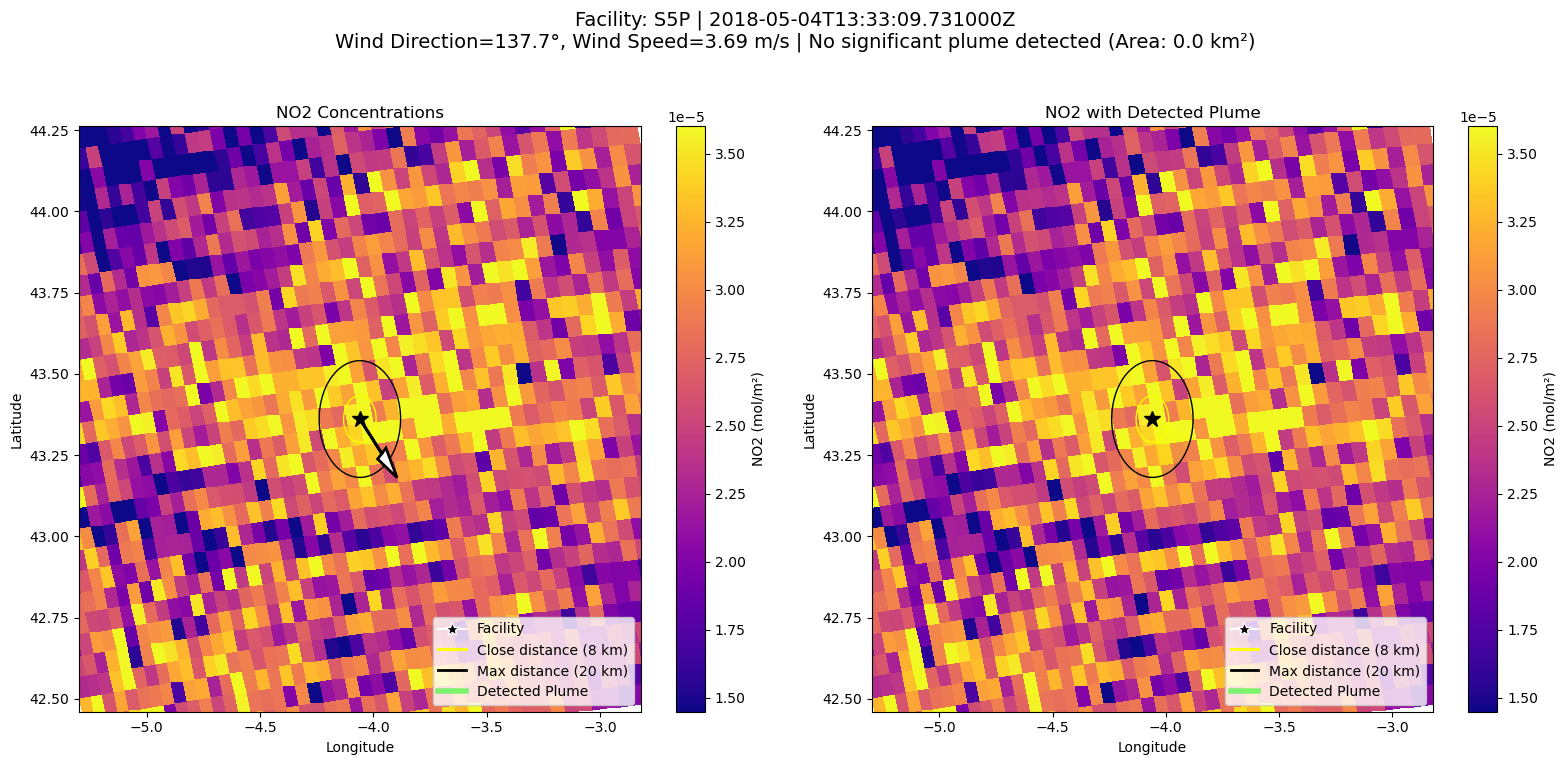

In [47]:
csv_file_path = '/net/fs06/d3/rzhuang/TROPOMI_world/data/valid_tropomi_emissions_6000.csv'
fig = process_zoomed_data(csv_file_path, row_idx=8095, zoom_radius_km=100)

In [8]:
import pandas as pd
import os

def load_simplemaps_cities(filepath):
    """
    Loads city data from the SimpleMaps World Cities Basic CSV file.

    Args:
        filepath (str): The full path to the worldcities.csv file.

    Returns:
        pandas.DataFrame: A DataFrame containing city data with columns like
                          'name', 'latitude', 'longitude', 'population', etc.,
                          or None if loading fails.
    """
    print(f"Attempting to load SimpleMaps city data from: {filepath}")

    # Check if the file exists
    if not os.path.exists(filepath):
        print(f"Error: File not found at the specified path: {filepath}")
        return None

    # Columns we are most interested in (based on typical SimpleMaps structure)
    # Adjust these if your specific version has different names
    relevant_columns = ['city_ascii', 'lat', 'lng', 'country', 'population', 'id']
    # We'll rename some later for consistency

    cities_df = None
    try:
        # Use pandas read_csv
        cities_df = pd.read_csv(
            filepath,
            encoding='utf-8',  # Often needed for city names
            low_memory=False
        )
        print(f"Successfully loaded {len(cities_df):,} records from the CSV file.")

        # --- Data Cleaning and Selection ---

        # 1. Check if required columns exist (latitude/longitude are essential)
        required_for_use = ['latitude', 'longitude']
        missing_cols = [col for col in required_for_use if col not in cities_df.columns]
        if missing_cols:
            print(f"Error: Essential columns missing from CSV: {missing_cols}")
            return None

        # Select a working subset of columns (including optional ones if they exist)
        cols_to_keep = [col for col in relevant_columns if col in cities_df.columns]
        cities_df = cities_df[cols_to_keep].copy() # Use .copy() to avoid SettingWithCopyWarning

        # 2. Rename columns for consistency
        rename_map = {
            'city_ascii': 'name', # Use ascii name for broader compatibility
            'lat': 'latitude',
            'lng': 'longitude'
        }
        cities_df.rename(columns=rename_map, inplace=True)
        # Keep 'population' as is, if it exists

        # 3. Convert latitude, longitude, population to numeric types
        cities_df['latitude'] = pd.to_numeric(cities_df['latitude'], errors='coerce')
        cities_df['longitude'] = pd.to_numeric(cities_df['longitude'], errors='coerce')
        # Population might not be present or might have non-numeric placeholders in free versions
        if 'population' in cities_df.columns:
             cities_df['population'] = pd.to_numeric(cities_df['population'], errors='coerce')
        else:
             print("Note: 'population' column not found or not selected.")


        # 4. Remove rows where essential data (lat, lon) is missing
        initial_count = len(cities_df)
        cities_df.dropna(subset=['latitude', 'longitude'], inplace=True)
        removed_count = initial_count - len(cities_df)
        if removed_count > 0:
            print(f"Removed {removed_count:,} rows with missing latitude or longitude.")

        # 5. Handle population NaNs (optional: fill with 0 or keep as NaN)
        # If you want to treat missing population as 0 for filtering:
        if 'population' in cities_df.columns:
             cities_df['population'].fillna(0, inplace=True)
             cities_df['population'] = cities_df['population'].astype(int)
             print("Filled missing population values with 0.")


        print(f"Finished processing. Returning DataFrame with {len(cities_df):,} cities.")
        return cities_df

    except FileNotFoundError: # Should be caught by the initial check, but good practice
        print(f"Error: File not found at the specified path: {filepath}")
        return None
    except Exception as e:
        print(f"An error occurred while loading or processing the file: {e}")
        return None

# --- Example Usage ---

# **Important:** Replace this path with the actual location of your worldcities.csv file.
file_location = '/net/fs06/d3/rzhuang/TROPOMI_world/data/worldcities.csv'

# Load the data
city_dataframe_sm = load_simplemaps_cities(file_location)

# Check if loading was successful and display sample data
if city_dataframe_sm is not None:
    print("\n--- Sample Loaded SimpleMaps City Data ---")
    print(city_dataframe_sm.head())

    print("\n--- DataFrame Info ---")
    city_dataframe_sm.info()

    # --- How to use it later ---
    # For example, get coordinates of cities with population > 500,000 (if population exists)
    if 'population' in city_dataframe_sm.columns:
        large_cities_sm = city_dataframe_sm[city_dataframe_sm['population'] > 500000].copy()
        # Create the list of (latitude, longitude) tuples
        interfering_city_coords_sm = list(zip(large_cities_sm['latitude'], large_cities_sm['longitude']))
        print(f"\nFound {len(interfering_city_coords_sm)} cities with population > 500,000.")
        if interfering_city_coords_sm:
            print("First 10 interfering city coordinates (lat, lon):")
            print(interfering_city_coords_sm[:10])
    else:
         # If no population data, maybe just take all cities found?
         # Or filter based on other criteria if available (e.g., country capitals)
         all_city_coords_sm = list(zip(city_dataframe_sm['latitude'], city_dataframe_sm['longitude']))
         print("\nPopulation data not available for filtering. Extracted all city coordinates.")
         print(f"Total cities loaded: {len(all_city_coords_sm)}")
         if all_city_coords_sm:
              print("First 10 interfering city coordinates (lat, lon):")
              print(all_city_coords_sm[:10])

    # Remember: The SimpleMaps Basic license requires attribution (a link back)
    # if you use this data publicly. Check their website for current terms.
    print("\nReminder: Check SimpleMaps license terms for attribution requirements if using this data publicly.")

else:
    print("\nSimpleMaps city data loading failed.")

Attempting to load SimpleMaps city data from: /net/fs06/d3/rzhuang/TROPOMI_world/data/worldcities.csv
Successfully loaded 47,539 records from the CSV file.
An error occurred while loading or processing the file: 'latitude'

SimpleMaps city data loading failed.


In [37]:
df = pd.read_csv('../data/power_plants_with_combined_nearby_stats_parallel_debug.csv')

In [11]:
import pandas as pd
import numpy as np
import os
import io
from math import radians, cos, sin, asin, sqrt

# --- Haversine Function (Copied from previous example) ---
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers between two points
    on the earth (specified in decimal degrees). Handles NaN inputs.
    """
    if any(pd.isna(x) for x in [lon1, lat1, lon2, lat2]):
        return np.inf
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371 # Radius of earth in kilometers.
    return c * r

def load_clean_cities_geoduplicates(data_source, distance_threshold_km=20):
    """
    Loads and cleans city data, removing geographical duplicates based on name,
    country, and proximity. Keeps the most populous entry among close duplicates.

    Args:
        data_source (str): Filepath or string containing CSV data.
        distance_threshold_km (float): Max distance (km) to consider entries
                                       as geographical duplicates.

    Returns:
        tuple: (pandas.DataFrame, pandas.DataFrame)
               - Cleaned DataFrame with unique geographical cities.
               - DataFrame of entries dropped due to being geographical duplicates.
               Returns (None, None) on failure.
    """
    print(f"Attempting to load and clean city data...")
    print(f"Using distance threshold for duplicates: {distance_threshold_km} km")

    # --- Initial Loading and Setup (similar to previous) ---
    cities_df = None
    try:
        if isinstance(data_source, str) and '\n' in data_source:
             print("Loading data from string.")
             cities_df = pd.read_csv(io.StringIO(data_source), encoding='utf-8', low_memory=False)
        elif isinstance(data_source, str) and os.path.exists(data_source):
             print(f"Loading data from filepath: {data_source}")
             cities_df = pd.read_csv(data_source, encoding='utf-8', low_memory=False)
        else:
             print("Error: Invalid data source.")
             return None, None
        print(f"Successfully loaded {len(cities_df):,} initial records.")
    except Exception as e:
        print(f"Error during initial loading: {e}")
        return None, None

    # Define columns and perform initial check/rename
    input_lat_col = 'lat'; input_lon_col = 'lng'; input_name_col = 'city_ascii';
    input_country_col = 'country'; input_pop_col = 'population'; input_id_col = 'id'
    std_name_col = 'name'; std_lat_col = 'latitude'; std_lon_col = 'longitude';
    std_country_col = 'country'; std_pop_col = 'population'; std_id_col = 'id'

    required_input_cols_map = {
        std_name_col: input_name_col if input_name_col in cities_df.columns else 'city' if 'city' in cities_df.columns else None,
        std_lat_col: input_lat_col if input_lat_col in cities_df.columns else None,
        std_lon_col: input_lon_col if input_lon_col in cities_df.columns else None,
        std_country_col: input_country_col if input_country_col in cities_df.columns else None
    }
    if None in required_input_cols_map.values():
        print(f"Error: Essential input columns not found (need variations of city, lat, lng, country).")
        return None, None

    # Optional columns
    input_pop_col_found = input_pop_col if input_pop_col in cities_df.columns else None
    input_id_col_found = input_id_col if input_id_col in cities_df.columns else None

    cols_map = {v: k for k, v in required_input_cols_map.items() if v is not None}
    if input_pop_col_found: cols_map[input_pop_col_found] = std_pop_col
    if input_id_col_found: cols_map[input_id_col_found] = std_id_col

    cities_df = cities_df[list(cols_map.keys())].copy()
    cities_df.rename(columns=cols_map, inplace=True)

    # Add original index column to track rows
    cities_df['original_index'] = cities_df.index

    # --- Convert, NaN Check (Ensure population exists for logic) ---
    cities_df[std_lat_col] = pd.to_numeric(cities_df[std_lat_col], errors='coerce')
    cities_df[std_lon_col] = pd.to_numeric(cities_df[std_lon_col], errors='coerce')
    if std_pop_col not in cities_df.columns:
         print("Error: Population column is required for duplicate removal logic.")
         return None, None
    cities_df[std_pop_col] = pd.to_numeric(cities_df[std_pop_col], errors='coerce')

    initial_count = len(cities_df)
    cols_to_check_nan = [std_lat_col, std_lon_col, std_name_col, std_country_col, std_pop_col]
    cities_df.dropna(subset=cols_to_check_nan, inplace=True)
    if len(cities_df) < initial_count:
        print(f"Removed {initial_count - len(cities_df):,} rows due to NaN values.")
    if cities_df.empty: return cities_df, pd.DataFrame()

    # --- Geographical Duplicate Removal Logic ---
    indices_to_keep = set()
    indices_to_drop = set()

    print("Processing groups to identify geographical duplicates...")
    # Group by name and country
    grouped = cities_df.groupby([std_name_col, std_country_col])

    for _, group_df in grouped:
        if len(group_df) == 1:
            # Only one entry for this name/country, keep it
            indices_to_keep.add(group_df.iloc[0]['original_index'])
            continue

        # Multiple entries exist, sort by population (desc) and original index (asc) as tie-breaker
        group_sorted = group_df.sort_values(
            [std_pop_col, 'original_index'], ascending=[False, True]
        )

        # Keep track of the entries confirmed to be kept within this group
        kept_in_group_indices = []
        kept_in_group_coords = []

        for idx, row in group_sorted.iterrows(): # idx is the original index from cities_df
            is_duplicate = False
            current_coords = (row[std_lon_col], row[std_lat_col])

            # Compare with already kept items *within this specific group*
            for kept_coords in kept_in_group_coords:
                distance = haversine(current_coords[0], current_coords[1], kept_coords[0], kept_coords[1])
                if distance <= distance_threshold_km:
                    is_duplicate = True
                    break # Found a close match, no need to check others

            if is_duplicate:
                indices_to_drop.add(row['original_index'])
            else:
                # This one is far enough from others kept so far in this group
                indices_to_keep.add(row['original_index'])
                # Add its index and coords to the list for future comparisons within this group
                kept_in_group_indices.append(row['original_index'])
                kept_in_group_coords.append(current_coords)

    # --- Create Final DataFrames ---
    # Ensure no index is in both sets (shouldn't happen with this logic, but good practice)
    conflicting_indices = indices_to_keep.intersection(indices_to_drop)
    if conflicting_indices:
        print(f"Warning: {len(conflicting_indices)} indices found in both keep and drop sets. Review logic.")
        # Prioritize keeping?
        indices_to_drop = indices_to_drop - conflicting_indices

    # Select rows based on original index
    cities_kept_df = cities_df[cities_df['original_index'].isin(indices_to_keep)].copy()
    cities_dropped_df = cities_df[cities_df['original_index'].isin(indices_to_drop)].copy()

    # Drop the helper column
    cities_kept_df.drop(columns=['original_index'], inplace=True)
    cities_dropped_df.drop(columns=['original_index'], inplace=True)

    # --- Final Type Conversion on Kept Data ---
    if std_pop_col in cities_kept_df.columns:
        cities_kept_df[std_pop_col] = cities_kept_df[std_pop_col].astype(float).astype(pd.Int64Dtype())

    print(f"Finished processing. Kept {len(cities_kept_df)} cities, dropped {len(cities_dropped_df)} geographical duplicates.")
    return cities_kept_df.reset_index(drop=True), cities_dropped_df.reset_index(drop=True)


# --- Create More Realistic Sample Data ---
# Springfield IL vs Springfield MA
# London UK vs London Canada
# Paris France vs Paris USA (Texas)
# Duplicate City Utopia (Close coordinates, different populations)
# Duplicate City Utopia (Close coordinates, same high population)
csv_file_path = '/net/fs06/d3/rzhuang/TROPOMI_world/data/worldcities.csv'
csv_data_geo = pd.read_csv(csv_file_path, low_memory=False)

# --- Run the function ---
DISTANCE_THRESHOLD = 50 # Define the proximity threshold in km
cities_geo_cleaned, cities_geo_dropped = load_clean_cities_geoduplicates(
    '/net/fs06/d3/rzhuang/TROPOMI_world/data/worldcities.csv',
    distance_threshold_km=DISTANCE_THRESHOLD
)

# --- Analyze and Display Results ---
if cities_geo_cleaned is not None:
    print("\n" + "="*60)
    print("      FINAL GEOGRAPHICALLY UNIQUE CITIES DATAFRAME")
    print("="*60)
    print(cities_geo_cleaned.sort_values(['country', 'name']))

    print("\n" + "="*60)
    print("      DROPPED GEOGRAPHICAL DUPLICATES DATAFRAME")
    print("="*60)
    if not cities_geo_dropped.empty:
        # Sort dropped cities for clarity
        cities_geo_dropped_sorted = cities_geo_dropped.sort_values(['country', 'name', 'population'], ascending=[True, True, False])
        print(cities_geo_dropped_sorted)

        print("\n" + "="*60)
        print("      ANALYSIS OF GEOGRAPHICAL DROPS")
        print("="*60)
        # Iterate through dropped items and explain why relative to kept items in the same group
        for index, dropped_row in cities_geo_dropped_sorted.iterrows():
            dropped_name = dropped_row['name']
            dropped_country = dropped_row['country']
            dropped_pop = dropped_row['population']
            dropped_coords = (dropped_row['longitude'], dropped_row['latitude'])
            print(f"\n- Analyzing Dropped: ID {dropped_row.get('id', 'N/A')}, {dropped_name}, {dropped_country}, Pop: {dropped_pop:,.0f}")

            # Find kept entries with the same name/country
            kept_rows_df = cities_geo_cleaned[
                (cities_geo_cleaned['name'] == dropped_name) &
                (cities_geo_cleaned['country'] == dropped_country)
            ]

            if not kept_rows_df.empty:
                 print(f"  Comparing against {len(kept_rows_df)} kept entry/entries for '{dropped_name}, {dropped_country}':")
                 found_close_kept = False
                 for _, kept_row in kept_rows_df.iterrows():
                    kept_pop = kept_row['population']
                    kept_coords = (kept_row['longitude'], kept_row['latitude'])
                    kept_id = kept_row.get('id', 'N/A')
                    distance = haversine(dropped_coords[0], dropped_coords[1], kept_coords[0], kept_coords[1])

                    print(f"    - Kept ID: {kept_id}, Pop: {kept_pop:,.0f}, Dist: {distance:.2f} km")

                    if distance <= DISTANCE_THRESHOLD:
                        found_close_kept = True
                        if dropped_pop < kept_pop:
                             print(f"      >> Reason: Dropped because it's within {distance:.2f} km of a MORE populous kept entry (ID {kept_id}).")
                        elif dropped_pop == kept_pop:
                             print(f"      >> Reason: Dropped because it's within {distance:.2f} km of an EQUALLY populous kept entry (ID {kept_id}) and had a higher original index/lower priority.")
                        else: # Should not happen if sorting worked
                             print(f"      >> Reason: Dropped because it's within {distance:.2f} km of kept entry (ID {kept_id}), but pop comparison unclear (Anomaly?).")

                 if not found_close_kept:
                      print("    !! Anomaly: This item was dropped, but no kept item found within the distance threshold. Check grouping/comparison logic.")

            else:
                 print("  !! Could not find any corresponding kept city in the cleaned data. (Unexpected)")

    else:
        print("No geographical duplicates were dropped.")
    print("="*60)

else:
    print("\nCity data loading and cleaning failed.")

Attempting to load and clean city data...
Using distance threshold for duplicates: 50 km
Loading data from filepath: /net/fs06/d3/rzhuang/TROPOMI_world/data/worldcities.csv
Successfully loaded 47,539 initial records.
Error: Essential input columns not found (need variations of city, lat, lng, country).

City data loading and cleaning failed.


In [51]:
import pandas as pd
df = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plants_with_combined_nearby_stats_parallel_debug.csv')

In [52]:
df

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,2.0,524059.0,2.0,524059.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,3.0,186270.0,8.0,1245774.0,41.0,5705546.0
2,CoCO2_11814,USA,coal,-78.675759,41.491466,6.542279e+05,29651.599383,0.000000,7229.197083,1.856072,...,30635.968430,96.786885,0.0,0.0,0.0,0.0,0.0,0.0,12.0,3773804.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,23.0,20365905.0,38.0,21902917.0,45.0,22953491.0
4,CoCO2_10835,SAU,oil,39.555858,20.627494,1.271810e+07,28471.290029,87519.805057,4957.941986,508.044048,...,71774.819908,39.667519,0.0,0.0,0.0,0.0,2.0,2499924.0,6.0,7988490.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13136,CoCO2_13067,USA,natural gas,-96.862100,42.269100,1.744443e+01,0.000000,0.000000,0.000000,0.000987,...,5197.969700,0.000000,0.0,0.0,1.0,111361.0,1.0,111361.0,6.0,1553727.0
13137,CoCO2_13859,USA,oil,-162.286322,63.521047,2.461664e+03,0.000000,0.000000,0.000000,0.099684,...,47.805498,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13138,CoCO2_13863,USA,oil,-165.108575,60.530142,2.199927e+03,0.000000,0.000000,0.000000,0.089085,...,0.000000,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,7.0,2503826.0,19.0,3635107.0,45.0,11008544.0,64.0,14863829.0


In [53]:
df.dropna()

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,2.0,524059.0,2.0,524059.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,3.0,186270.0,8.0,1245774.0,41.0,5705546.0
2,CoCO2_11814,USA,coal,-78.675759,41.491466,6.542279e+05,29651.599383,0.000000,7229.197083,1.856072,...,30635.968430,96.786885,0.0,0.0,0.0,0.0,0.0,0.0,12.0,3773804.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,23.0,20365905.0,38.0,21902917.0,45.0,22953491.0
4,CoCO2_10835,SAU,oil,39.555858,20.627494,1.271810e+07,28471.290029,87519.805057,4957.941986,508.044048,...,71774.819908,39.667519,0.0,0.0,0.0,0.0,2.0,2499924.0,6.0,7988490.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13136,CoCO2_13067,USA,natural gas,-96.862100,42.269100,1.744443e+01,0.000000,0.000000,0.000000,0.000987,...,5197.969700,0.000000,0.0,0.0,1.0,111361.0,1.0,111361.0,6.0,1553727.0
13137,CoCO2_13859,USA,oil,-162.286322,63.521047,2.461664e+03,0.000000,0.000000,0.000000,0.099684,...,47.805498,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13138,CoCO2_13863,USA,oil,-165.108575,60.530142,2.199927e+03,0.000000,0.000000,0.000000,0.089085,...,0.000000,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,7.0,2503826.0,19.0,3635107.0,45.0,11008544.0,64.0,14863829.0


In [43]:
df = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv')

In [44]:
df

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,3.0,565064.0,3.0,565064.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,6.0,270191.0,24.0,1676080.0,113.0,7568889.0
2,CoCO2_11814,USA,coal,-78.675759,41.491466,6.542279e+05,29651.599383,0.000000,7229.197083,1.856072,...,30635.968430,96.786885,0.0,0.0,0.0,0.0,2.0,44428.0,63.0,5018920.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,33.0,20629655.0,60.0,22458560.0,81.0,23953471.0
4,CoCO2_10835,SAU,oil,39.555858,20.627494,1.271810e+07,28471.290029,87519.805057,4957.941986,508.044048,...,71774.819908,39.667519,0.0,0.0,0.0,0.0,2.0,2499924.0,7.0,8021809.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13136,CoCO2_13067,USA,natural gas,-96.862100,42.269100,1.744443e+01,0.000000,0.000000,0.000000,0.000987,...,5197.969700,0.000000,0.0,0.0,1.0,111361.0,4.0,179895.0,12.0,1687025.0
13137,CoCO2_13859,USA,oil,-162.286322,63.521047,2.461664e+03,0.000000,0.000000,0.000000,0.099684,...,47.805498,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13138,CoCO2_13863,USA,oil,-165.108575,60.530142,2.199927e+03,0.000000,0.000000,0.000000,0.089085,...,0.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [45]:
df.dropna()

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,3.0,565064.0,3.0,565064.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,6.0,270191.0,24.0,1676080.0,113.0,7568889.0
2,CoCO2_11814,USA,coal,-78.675759,41.491466,6.542279e+05,29651.599383,0.000000,7229.197083,1.856072,...,30635.968430,96.786885,0.0,0.0,0.0,0.0,2.0,44428.0,63.0,5018920.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,33.0,20629655.0,60.0,22458560.0,81.0,23953471.0
4,CoCO2_10835,SAU,oil,39.555858,20.627494,1.271810e+07,28471.290029,87519.805057,4957.941986,508.044048,...,71774.819908,39.667519,0.0,0.0,0.0,0.0,2.0,2499924.0,7.0,8021809.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13134,CoCO2_11581,USA,biomass,-118.126700,34.135800,0.000000e+00,0.000000,0.000000,0.000000,0.056984,...,16195.229974,0.000000,32.0,1721585.0,108.0,19364243.0,167.0,27300081.0,216.0,33627212.0
13135,CoCO2_12464,USA,natural gas,-73.211111,41.168056,0.000000e+00,0.000000,0.000000,0.000000,0.815149,...,18323.796607,0.000000,4.0,1091171.0,55.0,4773157.0,199.0,40020617.0,336.0,46586291.0
13136,CoCO2_13067,USA,natural gas,-96.862100,42.269100,1.744443e+01,0.000000,0.000000,0.000000,0.000987,...,5197.969700,0.000000,0.0,0.0,1.0,111361.0,4.0,179895.0,12.0,1687025.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [7]:
import pandas as pd
import os

csv = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv')

In [6]:
csv[csv['percentage_emission_20km']<50]

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
10,CoCO2_10843,SAU,oil,39.033520,22.673151,8.237493e+06,18440.807791,56686.433995,3211.250881,329.059296,...,62862.566830,29.335117,0.0,0.0,0.0,0.0,1.0,63445.0,5.0,7583753.0
13,CoCO2_14878,DEU,coal,6.669690,50.993570,2.720000e+07,18000.000000,10600.000000,5140.000000,99.999000,...,69876.713967,25.759654,10.0,498931.0,96.0,7593275.0,247.0,15814131.0,447.0,25462124.0
30,CoCO2_00011,AGO,oil,13.305068,-8.813623,1.061635e+06,12285.516133,2106.835829,2750.209283,41.696859,...,26731.333473,45.959234,4.0,11876210.0,7.0,12676014.0,7.0,12676014.0,17.0,13345842.0
35,CoCO2_15684,SRB,coal,20.004968,44.653846,6.334398e+06,12000.000000,93900.000000,499.999000,67.928657,...,43152.587488,27.808298,1.0,17462.0,18.0,2114288.0,48.0,3766609.0,99.0,6432741.0
42,CoCO2_10784,SAU,natural gas,49.896000,26.850000,1.155003e+07,11428.005852,578.264419,5731.456491,205.882815,...,46564.937056,24.542084,0.0,0.0,6.0,1288550.0,15.0,3274392.0,20.0,4351474.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13134,CoCO2_11581,USA,biomass,-118.126700,34.135800,0.000000e+00,0.000000,0.000000,0.000000,0.056984,...,16195.229974,0.000000,32.0,1721585.0,108.0,19364243.0,167.0,27300081.0,216.0,33627212.0
13135,CoCO2_12464,USA,natural gas,-73.211111,41.168056,0.000000e+00,0.000000,0.000000,0.000000,0.815149,...,18323.796607,0.000000,4.0,1091171.0,55.0,4773157.0,199.0,40020617.0,336.0,46586291.0
13136,CoCO2_13067,USA,natural gas,-96.862100,42.269100,1.744443e+01,0.000000,0.000000,0.000000,0.000987,...,5197.969700,0.000000,0.0,0.0,1.0,111361.0,4.0,179895.0,12.0,1687025.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [2]:
csv

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,3.0,565064.0,3.0,565064.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,6.0,270191.0,24.0,1676080.0,113.0,7568889.0
2,CoCO2_11814,USA,coal,-78.675759,41.491466,6.542279e+05,29651.599383,0.000000,7229.197083,1.856072,...,30635.968430,96.786885,0.0,0.0,0.0,0.0,2.0,44428.0,63.0,5018920.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,33.0,20629655.0,60.0,22458560.0,81.0,23953471.0
4,CoCO2_10835,SAU,oil,39.555858,20.627494,1.271810e+07,28471.290029,87519.805057,4957.941986,508.044048,...,71774.819908,39.667519,0.0,0.0,0.0,0.0,2.0,2499924.0,7.0,8021809.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13136,CoCO2_13067,USA,natural gas,-96.862100,42.269100,1.744443e+01,0.000000,0.000000,0.000000,0.000987,...,5197.969700,0.000000,0.0,0.0,1.0,111361.0,4.0,179895.0,12.0,1687025.0
13137,CoCO2_13859,USA,oil,-162.286322,63.521047,2.461664e+03,0.000000,0.000000,0.000000,0.099684,...,47.805498,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13138,CoCO2_13863,USA,oil,-165.108575,60.530142,2.199927e+03,0.000000,0.000000,0.000000,0.089085,...,0.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [3]:
csv[csv['nearby_cities_count_50km']>1]

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,3.0,565064.0,3.0,565064.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,6.0,270191.0,24.0,1676080.0,113.0,7568889.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,33.0,20629655.0,60.0,22458560.0,81.0,23953471.0
5,CoCO2_10833,SAU,oil,47.015529,24.416537,1.000267e+07,22392.409461,68833.526993,3899.376070,399.572002,...,48222.845731,46.435272,0.0,0.0,2.0,7288954.0,3.0,7308097.0,4.0,7902702.0
7,CoCO2_14874,DEU,coal,6.614886,51.037826,2.990000e+07,20200.000000,5640.000000,5810.000000,99.999000,...,69900.438967,28.898245,12.0,670541.0,97.0,7870056.0,257.0,16037669.0,456.0,25696659.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13133,CoCO2_15350,ITA,oil,16.603200,39.623100,1.789631e+02,0.000000,0.000000,0.150008,0.006245,...,2117.923300,0.000000,2.0,77076.0,9.0,405932.0,17.0,730529.0,88.0,3838274.0
13134,CoCO2_11581,USA,biomass,-118.126700,34.135800,0.000000e+00,0.000000,0.000000,0.000000,0.056984,...,16195.229974,0.000000,32.0,1721585.0,108.0,19364243.0,167.0,27300081.0,216.0,33627212.0
13135,CoCO2_12464,USA,natural gas,-73.211111,41.168056,0.000000e+00,0.000000,0.000000,0.000000,0.815149,...,18323.796607,0.000000,4.0,1091171.0,55.0,4773157.0,199.0,40020617.0,336.0,46586291.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [6]:
csv[csv['nearby_cities_count_20km']>0]

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,3.0,565064.0,3.0,565064.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,6.0,270191.0,24.0,1676080.0,113.0,7568889.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,33.0,20629655.0,60.0,22458560.0,81.0,23953471.0
6,CoCO2_11845,USA,coal,-84.756900,35.296400,2.008162e+06,20779.398530,1954.609453,5066.113477,18.201870,...,22693.396535,91.565837,1.0,72870.0,1.0,72870.0,8.0,674763.0,64.0,8692210.0
7,CoCO2_14874,DEU,coal,6.614886,51.037826,2.990000e+07,20200.000000,5640.000000,5810.000000,99.999000,...,69900.438967,28.898245,12.0,670541.0,97.0,7870056.0,257.0,16037669.0,456.0,25696659.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13133,CoCO2_15350,ITA,oil,16.603200,39.623100,1.789631e+02,0.000000,0.000000,0.150008,0.006245,...,2117.923300,0.000000,2.0,77076.0,9.0,405932.0,17.0,730529.0,88.0,3838274.0
13134,CoCO2_11581,USA,biomass,-118.126700,34.135800,0.000000e+00,0.000000,0.000000,0.000000,0.056984,...,16195.229974,0.000000,32.0,1721585.0,108.0,19364243.0,167.0,27300081.0,216.0,33627212.0
13135,CoCO2_12464,USA,natural gas,-73.211111,41.168056,0.000000e+00,0.000000,0.000000,0.000000,0.815149,...,18323.796607,0.000000,4.0,1091171.0,55.0,4773157.0,199.0,40020617.0,336.0,46586291.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [14]:
csv.columns

Index(['ID', 'ISO3', 'fuel', 'longitude', 'latitude', 'co2_emis_ty',
       'nox_emis_ty', 'sox_emis_ty', 'co_emis_ty', 'ch4_emis_ty',
       'ID_MonthFact', 'ID_WeekFact', 'ID_HourFact', 'ID_VertProf',
       'cumulative_NOx_sum', 'cumulative_CO2_sum', 'NOx_percentage',
       'CO2_percentage', 'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emission_50km',
       'nearby_plants_count_100km', 'total_emission_100km',
       'percentage_emission_100km', 'nearby_cities_count_20km',
       'nearby_cities_pop_20km', 'nearby_cities_count_50km',
       'nearby_cities_pop_50km', 'nearby_cities_count_100km',
       'nearby_cities_pop_100km', 'nearby_cities_count_200km',
       'nearby_cities_pop_200km'],
      dtype='object')

In [3]:
csv[csv['nearby_cities_pop_20km']>50000]

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,...,44548.165635,100.000000,1.0,395900.0,2.0,524059.0,3.0,565064.0,3.0,565064.0
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,...,32951.680000,91.345874,1.0,54338.0,6.0,270191.0,24.0,1676080.0,113.0,7568889.0
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,...,66466.570202,43.018977,9.0,18527215.0,33.0,20629655.0,60.0,22458560.0,81.0,23953471.0
6,CoCO2_11845,USA,coal,-84.756900,35.296400,2.008162e+06,20779.398530,1954.609453,5066.113477,18.201870,...,22693.396535,91.565837,1.0,72870.0,1.0,72870.0,8.0,674763.0,64.0,8692210.0
7,CoCO2_14874,DEU,coal,6.614886,51.037826,2.990000e+07,20200.000000,5640.000000,5810.000000,99.999000,...,69900.438967,28.898245,12.0,670541.0,97.0,7870056.0,257.0,16037669.0,456.0,25696659.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13133,CoCO2_15350,ITA,oil,16.603200,39.623100,1.789631e+02,0.000000,0.000000,0.150008,0.006245,...,2117.923300,0.000000,2.0,77076.0,9.0,405932.0,17.0,730529.0,88.0,3838274.0
13134,CoCO2_11581,USA,biomass,-118.126700,34.135800,0.000000e+00,0.000000,0.000000,0.000000,0.056984,...,16195.229974,0.000000,32.0,1721585.0,108.0,19364243.0,167.0,27300081.0,216.0,33627212.0
13135,CoCO2_12464,USA,natural gas,-73.211111,41.168056,0.000000e+00,0.000000,0.000000,0.000000,0.815149,...,18323.796607,0.000000,4.0,1091171.0,55.0,4773157.0,199.0,40020617.0,336.0,46586291.0
13139,CoCO2_12322,USA,natural gas,-121.899969,37.378422,0.000000e+00,0.000000,0.000000,0.000000,0.003298,...,10251.706432,0.000000,12.0,2689757.0,37.0,4198526.0,93.0,12389242.0,138.0,17020633.0


In [2]:
import xarray as xr

file_path = '/net/fs06/d3/rzhuang/TROPOMI_world/data/era5/e5bf81668420e99651013e79f2253bc3.nc'
ds = xr.open_dataset(file_path)

# Print full dataset summary (dims, coords, data_vars)
print(ds)

# Or just list variable names:
print("Data variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

<xarray.Dataset> Size: 73GB
Dimensions:     (valid_time: 8760, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 140kB ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 36GB ...
    sp          (valid_time, latitude, longitude) float32 36GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-22T21:13 GRIB to CDM+CF via cfgrib-0.9.1...
Data variables: ['sst', 'sp']
Coordinates: ['number', 'valid_time', 'latitud

In [3]:
import xarray as xr

ds = xr.open_dataset(
    '/net/fs06/d3/rzhuang/TROPOMI_world/data/era5/divergence.grib',
    engine='cfgrib'
)
print(ds)
print('vars:', list(ds.data_vars))
print('coords:', list(ds.coords))

Ignoring index file '/net/fs06/d3/rzhuang/TROPOMI_world/data/era5/divergence.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 218GB
Dimensions:        (time: 8760, isobaricInhPa: 6, latitude: 721, longitude: 1440)
Coordinates:
    number         int64 8B ...
  * time           (time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31T23:00:00
    step           timedelta64[ns] 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 48B 1e+03 950.0 900.0 ... 800.0 750.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time     (time) datetime64[ns] 70kB ...
Data variables:
    d              (time, isobaricInhPa, latitude, longitude) float32 218GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2

/net/fs01/home/rzhuang/miniforge3/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [4]:
ds

<xarray.Dataset> Size: 218GB
Dimensions:        (time: 8760, isobaricInhPa: 6, latitude: 721, longitude: 1440)
Coordinates:
    number         int64 8B ...
  * time           (time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31T23:00:00
    step           timedelta64[ns] 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 48B 1e+03 950.0 900.0 ... 800.0 750.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time     (time) datetime64[ns] 70kB ...
Data variables:
    d              (time, isobaricInhPa, latitude, longitude) float32 218GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-21T21:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
import pandas as pd

df = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/valid_tropomi_emissions_new_dropna_wind.csv')

In [5]:
df

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission
0,CoCO2_10376,63.042747,147.206474,2018-05-01T01:05:50.656000Z,-1.008826,0.582611,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1156.275386
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362
3,CoCO2_13805,53.892459,-166.538185,2018-05-01T01:01:19.583000Z,3.940873,0.283496,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,719.416674
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229
...,...,...,...,...,...,...,...,...,...,...
1799495,CoCO2_00370,-34.847500,138.581800,2018-12-30T04:43:54.158000Z,4.184148,6.345754,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,AUS,226.303293
1799496,CoCO2_10583,43.125800,131.878100,2018-12-30T05:05:53.888000Z,-0.278393,-9.144186,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,226.132820
1799497,CoCO2_00389,-20.442336,140.718062,2018-12-30T04:47:44.193000Z,-3.791403,1.310109,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,AUS,222.681490
1799498,CoCO2_02222,46.883501,127.480333,2018-12-30T05:06:57.606000Z,2.240561,-0.196493,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,CHN,222.099175


In [1]:
import pandas as pd

df = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/processed_tropomi_with_all_vars.csv')

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

plt.rcdefaults()

# Load and clean data
df = pd.read_csv("/net/fs06/d3/rzhuang/TROPOMI_world/data/processed_tropomi_with_all_vars.csv")
# df = df.dropna()

In [2]:
df

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,cloud_pressure_crb,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance
0,CoCO2_10376,63.042747,147.206474,2018-05-01T01:05:50.656000Z,-1.008826,0.582611,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1156.275386,...,86644.476562,0.738964,0.8,0.686959,87250.046875,103.0,-0.487401,-1.008826,0.582611,3.903656e-16
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798,...,81141.843750,0.885998,0.8,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362,...,81141.843750,0.885998,0.8,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
3,CoCO2_13805,53.892459,-166.538185,2018-05-01T01:01:19.583000Z,3.940873,0.283496,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,719.416674,...,79384.039062,0.598926,0.8,0.522829,81067.226562,0.0,0.362723,3.940873,0.283496,5.601286e-16
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229,...,91991.648438,0.543687,0.8,0.540928,93340.585938,103.0,0.009146,-2.278011,-1.082761,2.277232e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799495,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,96570.335938,0.122034,0.8,0.108481,97235.867188,255.0,-0.683775,-9.188789,-0.178532,6.894267e-18
1799496,CoCO2_13711,58.730417,-157.007222,2018-12-31T23:27:52.871000Z,-3.818447,5.638376,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,338.635580,...,30620.513672,0.637049,0.8,0.573116,35230.398438,103.0,-1.248347,-3.818447,5.638376,6.117279e-17
1799497,CoCO2_14322,20.896884,-156.462696,2018-12-31T23:17:44.845000Z,-4.541558,-2.956448,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,319.218906,...,84345.304688,0.100843,0.8,0.104031,96322.710938,255.0,-0.644553,-4.541558,-2.956448,1.483955e-16
1799498,CoCO2_14329,19.704100,-155.060700,2018-12-31T23:17:17.846000Z,-3.848017,0.388110,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,304.193051,...,85328.789062,0.715525,0.8,0.595558,85847.859375,0.0,-0.689705,-3.848017,0.388110,3.695632e-15


In [3]:
df = df.drop(columns=['sst'])

In [4]:
df[np.isnan(df['blh'])]

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,blh
600,CoCO2_06100,5.681997,-0.048466,2018-05-02T14:00:23.171000Z,2.640821,4.175822,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GHA,574.433689,NaN
1279,CoCO2_05966,35.800000,-0.192400,2018-05-03T13:49:57.806000Z,4.523482,-2.707978,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,DZA,2430.423397,NaN
1284,CoCO2_15782,53.735239,-0.242973,2018-05-03T13:55:09.919000Z,3.212892,2.959973,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,2350.000000,NaN
1318,CoCO2_15762,53.601600,-0.144807,2018-05-03T13:55:07.759000Z,3.042636,2.888241,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,1190.000000,NaN
1325,CoCO2_05984,35.806400,-0.247600,2018-05-03T13:49:57.806000Z,4.226529,-1.928499,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,DZA,998.209610,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1785740,CoCO2_15764,53.636835,-0.238499,2018-12-31T11:37:27.759000Z,4.324705,1.987731,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,703.000000,NaN
1785797,CoCO2_16091,51.485479,-0.046437,2018-12-31T11:36:58.599000Z,2.629753,0.007046,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,568.000000,NaN
1785882,CoCO2_15788,52.807839,-0.132192,2018-12-31T11:37:16.959000Z,4.644295,0.874100,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,419.000000,NaN
1786118,CoCO2_16083,51.616222,-0.040539,2018-12-31T11:37:00.759000Z,2.859293,-0.204529,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,229.000000,NaN


In [5]:
df

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,cloud_pressure_crb,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance
0,CoCO2_10376,63.042747,147.206474,2018-05-01T01:05:50.656000Z,-1.008826,0.582611,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1156.275386,...,86644.476562,0.738964,0.800000,0.686959,87250.046875,103.0,-0.487401,-1.008826,0.582611,3.903656e-16
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798,...,81141.843750,0.885998,0.800000,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362,...,81141.843750,0.885998,0.800000,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229,...,91991.648438,0.543687,0.800000,0.540928,93340.585938,103.0,0.009146,-2.278011,-1.082761,2.277232e-15
7,CoCO2_10544,60.957500,46.484800,2018-05-01T01:17:42.359000Z,-0.299399,-2.542603,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,320.606088,...,64669.726562,0.782804,0.812127,0.695964,66484.710938,103.0,0.943092,-0.299399,-2.542603,7.691976e-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797816,CoCO2_06099,5.734903,0.013728,2018-12-31T13:04:23.361000Z,-0.106485,2.693144,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GHA,225.670378,...,94083.101562,0.185678,0.800000,0.246389,96402.757812,0.0,1.254690,-0.106485,2.693144,2.254616e-16
1797817,CoCO2_14748,51.158713,3.807275,2018-12-31T13:16:38.824000Z,2.839449,-0.431768,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,BEL,225.000000,...,90052.328125,0.650571,0.800000,0.607292,91500.570312,0.0,0.884321,2.839449,-0.431768,1.606353e-16
1797818,CoCO2_14738,51.234578,4.319203,2018-12-31T13:16:39.904000Z,2.995347,-0.204087,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,BEL,224.000000,...,89194.132812,0.776909,0.800000,0.668126,89504.460938,0.0,0.491719,2.995347,-0.204087,4.414833e-18
1797819,CoCO2_09740,6.882125,3.314591,2018-12-31T13:04:25.521000Z,0.278000,-0.088655,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,NGA,222.958219,...,54432.523438,0.028592,0.800000,0.257664,94715.367188,0.0,1.045948,0.278000,-0.088655,8.254385e-16


In [7]:
'surface_albedo' in df.columns

True

In [10]:
# df['wind'] = np.sqrt(df['wind_u']**2 + df['wind_v']**2)

df = df.dropna()

# print(X)
X = df.iloc[:,9:]
# X = df.loc['surface_albedo']

y = df["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.7251617276272126
Precision: 0.1287905126125082
Recall: 0.6197410000619618
F1 Score: 0.21326226012793176
Confusion Matrix:
 [[184709  67659]
 [  6137  10002]]
AUC: 0.7309149455178321
Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.73      0.83    252368
        True       0.13      0.62      0.21     16139

    accuracy                           0.73    268507
   macro avg       0.55      0.68      0.52    268507
weighted avg       0.92      0.73      0.80    268507

Kappa: 0.1263038553122764


In [17]:
# df['wind'] = np.sqrt(df['wind_u']**2 + df['wind_v']**2)

df = df.dropna()

# print(X)
# X = df.iloc[:,9:]
X = df[['t2m']]

y = df["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.44159370146774574
Precision: 0.06583942837487913
Recall: 0.6286015242580085
F1 Score: 0.1191944826289756
Confusion Matrix:
 [[108426 143942]
 [  5994  10145]]
AUC: 0.5437077016230255
Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.43      0.59    252368
        True       0.07      0.63      0.12     16139

    accuracy                           0.44    268507
   macro avg       0.51      0.53      0.36    268507
weighted avg       0.89      0.44      0.56    268507

Kappa: 0.011646181340692174


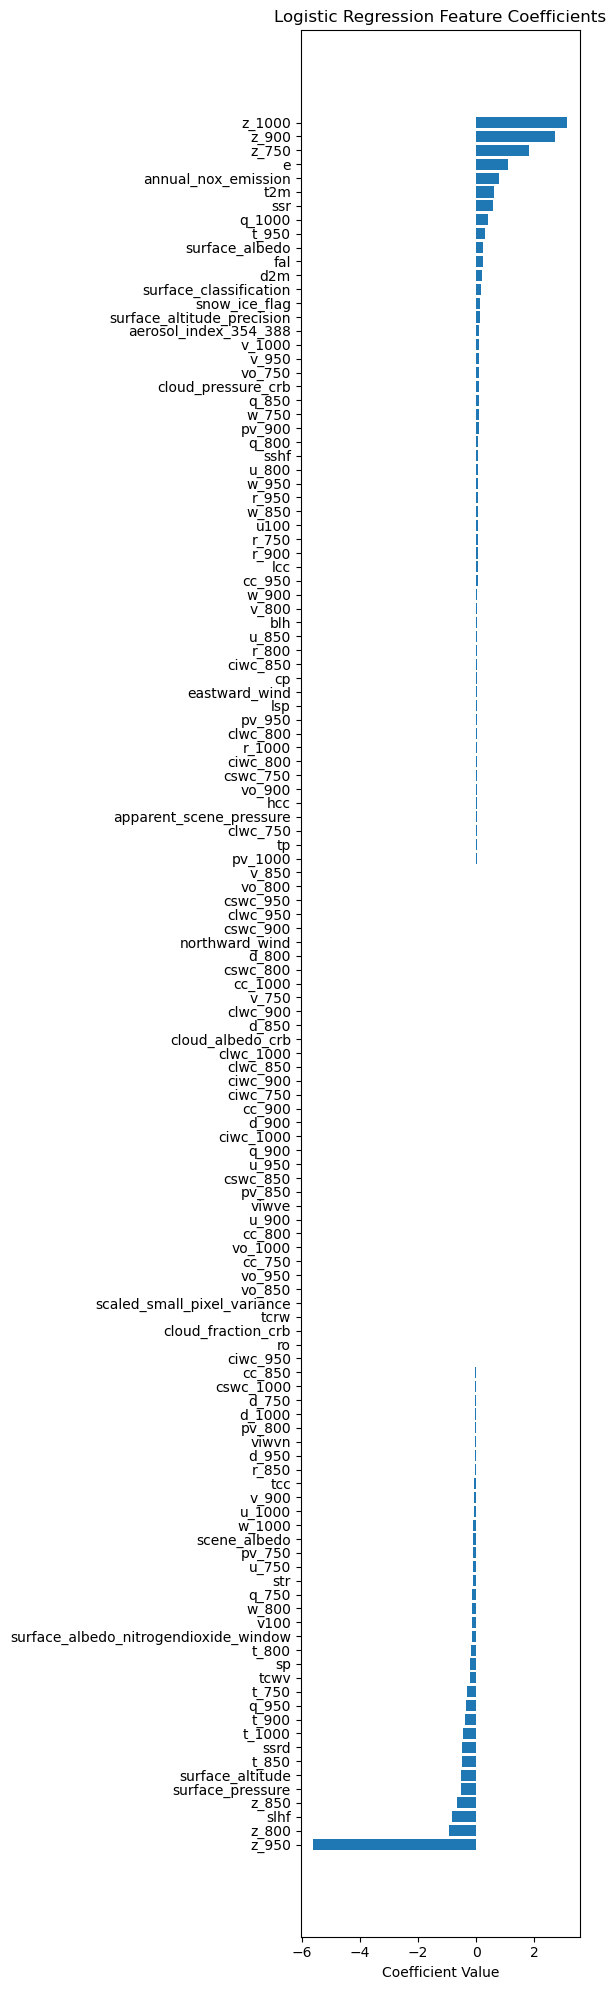

In [11]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [18]:
df

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,cloud_pressure_crb,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance
0,CoCO2_10376,63.042747,147.206474,2018-05-01T01:05:50.656000Z,-1.008826,0.582611,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1156.275386,...,86644.476562,0.738964,0.8,0.686959,87250.046875,103.0,-0.487401,-1.008826,0.582611,3.903656e-16
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798,...,81141.843750,0.885998,0.8,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362,...,81141.843750,0.885998,0.8,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
3,CoCO2_13805,53.892459,-166.538185,2018-05-01T01:01:19.583000Z,3.940873,0.283496,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,719.416674,...,79384.039062,0.598926,0.8,0.522829,81067.226562,0.0,0.362723,3.940873,0.283496,5.601286e-16
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229,...,91991.648438,0.543687,0.8,0.540928,93340.585938,103.0,0.009146,-2.278011,-1.082761,2.277232e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799495,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,96570.335938,0.122034,0.8,0.108481,97235.867188,255.0,-0.683775,-9.188789,-0.178532,6.894267e-18
1799496,CoCO2_13711,58.730417,-157.007222,2018-12-31T23:27:52.871000Z,-3.818447,5.638376,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,338.635580,...,30620.513672,0.637049,0.8,0.573116,35230.398438,103.0,-1.248347,-3.818447,5.638376,6.117279e-17
1799497,CoCO2_14322,20.896884,-156.462696,2018-12-31T23:17:44.845000Z,-4.541558,-2.956448,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,319.218906,...,84345.304688,0.100843,0.8,0.104031,96322.710938,255.0,-0.644553,-4.541558,-2.956448,1.483955e-16
1799498,CoCO2_14329,19.704100,-155.060700,2018-12-31T23:17:17.846000Z,-3.848017,0.388110,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,304.193051,...,85328.789062,0.715525,0.8,0.595558,85847.859375,0.0,-0.689705,-3.848017,0.388110,3.695632e-15


In [36]:
# Define the columns as strings
columns = ["location", "latitude", "longitude", "utc_time", "wind_u", "wind_v", "plume_label", 
           "file_path", "country", "annual_nox_emission", "blh", "d_1000", "d_950", "d_900", 
           "d_850", "d_800", "d_750", "e", "ro", "fal", "cc_1000", "cc_950", "cc_900", "cc_850", 
           "cc_800", "cc_750", "z_1000", "z_950", "z_900", "z_850", "z_800", "z_750", "tcc", 
           "lcc", "hcc", "pv_1000", "pv_950", "pv_900", "pv_850", "pv_800", "pv_750", "r_1000", 
           "r_950", "r_900", "r_850", "r_800", "r_750", "vo_1000", "vo_950", "vo_900", "vo_850", 
           "vo_800", "vo_750", "sp", "sst", "ciwc_1000", "ciwc_950", "ciwc_900", "ciwc_850", 
           "ciwc_800", "ciwc_750", "clwc_1000", "clwc_950", "clwc_900", "clwc_850", "clwc_800", 
           "clwc_750", "q_1000", "q_950", "q_900", "q_850", "q_800", "q_750", "cswc_1000", 
           "cswc_950", "cswc_900", "cswc_850", "cswc_800", "cswc_750", "sshf", "slhf", "str", 
           "ssr", "ssrd", "d2m", "t2m", "t_1000", "t_950", "t_900", "t_850", "t_800", "t_750", 
           "tcrw", "tcwv", "lsp", "tp", "cp", "viwvn", "viwve", "w_1000", "w_950", "w_900", 
           "w_850", "w_800", "w_750", "u_1000", "u_950", "u_900", "u_850", "u_800", "u_750", 
           "v100", "u100", "v_1000", "v_950", "v_900", "v_850", "v_800", "v_750", 
           "surface_altitude", "surface_altitude_precision", "surface_classification", 
           "surface_pressure", "surface_albedo", "surface_albedo_nitrogendioxide_window", 
           "cloud_pressure_crb", "cloud_fraction_crb", "cloud_albedo_crb", "scene_albedo", 
           "apparent_scene_pressure", "snow_ice_flag", "aerosol_index_354_388", "eastward_wind", 
           "northward_wind", "scaled_small_pixel_variance"]

# Now the loop should work
for i in range(len(columns)):
    # Check if the column exists in the DataFrame
    if columns[i] not in df.columns:
        print(f"Column '{columns[i]}' not found in DataFrame.")
        continue  # Skip to the next iteration if the column is missing
    # Check for NaN values in the specified column
    mask = df[columns[i]].isna()  # Assuming 'i' and 'df' are defined elsewhere in your code
    print(f"{columns[i]} NaNs: {mask.sum():,}/{len(df):,} ({mask.mean()*100:.1f}%)")

location NaNs: 0/1,799,500 (0.0%)
latitude NaNs: 0/1,799,500 (0.0%)
longitude NaNs: 0/1,799,500 (0.0%)
utc_time NaNs: 0/1,799,500 (0.0%)
wind_u NaNs: 0/1,799,500 (0.0%)
wind_v NaNs: 0/1,799,500 (0.0%)
plume_label NaNs: 0/1,799,500 (0.0%)
file_path NaNs: 0/1,799,500 (0.0%)
country NaNs: 0/1,799,500 (0.0%)
annual_nox_emission NaNs: 0/1,799,500 (0.0%)
blh NaNs: 455,538/1,799,500 (25.3%)
d_1000 NaNs: 455,538/1,799,500 (25.3%)
d_950 NaNs: 455,538/1,799,500 (25.3%)
d_900 NaNs: 455,538/1,799,500 (25.3%)
d_850 NaNs: 455,538/1,799,500 (25.3%)
d_800 NaNs: 455,538/1,799,500 (25.3%)
d_750 NaNs: 455,538/1,799,500 (25.3%)
e NaNs: 455,538/1,799,500 (25.3%)
ro NaNs: 455,538/1,799,500 (25.3%)
fal NaNs: 455,538/1,799,500 (25.3%)
cc_1000 NaNs: 455,538/1,799,500 (25.3%)
cc_950 NaNs: 455,538/1,799,500 (25.3%)
cc_900 NaNs: 455,538/1,799,500 (25.3%)
cc_850 NaNs: 455,538/1,799,500 (25.3%)
cc_800 NaNs: 455,538/1,799,500 (25.3%)
cc_750 NaNs: 455,538/1,799,500 (25.3%)
z_1000 NaNs: 455,538/1,799,500 (25.3%)
z_950

In [37]:
df.dropna()

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance,iso
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798,...,0.885998,0.800000,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17,2018-05-01 01:00:00
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362,...,0.885998,0.800000,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17,2018-05-01 01:00:00
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229,...,0.543687,0.800000,0.540928,93340.585938,103.0,0.009146,-2.278011,-1.082761,2.277232e-15,2018-05-01 01:00:00
8,CoCO2_10497,64.730500,177.499500,2018-05-01T01:04:27.498000Z,5.830154,-3.387597,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,251.258689,...,0.992543,0.829267,0.816107,98591.531250,60.0,-0.399723,5.830154,-3.387597,4.053539e-15,2018-05-01 01:00:00
10,CoCO2_10148,69.704514,170.289712,2018-05-01T01:05:59.296000Z,2.299983,-3.348973,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,242.675081,...,1.000000,0.834176,0.834176,90803.171875,103.0,-0.889914,2.299983,-3.348973,1.751940e-16,2018-05-01 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797743,CoCO2_03952,0.000000,0.000000,2018-12-31T13:02:52.643000Z,-3.463829,2.839813,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,CHN,288.889366,...,0.358546,0.800000,0.303707,50304.128906,255.0,-0.883583,-3.463829,2.839813,1.352382e-15,2018-12-31 13:00:00
1797745,CoCO2_15774,51.380464,0.761354,2018-12-31T13:16:44.224000Z,2.661839,0.322161,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,287.000000,...,0.875235,0.800000,0.715999,90812.328125,0.0,-0.698265,2.661839,0.322161,1.390636e-17,2018-12-31 13:00:00
1797789,CoCO2_16103,50.802043,0.049194,2018-12-31T13:16:34.504000Z,2.492760,-0.781077,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,246.000000,...,0.656956,0.800000,0.567314,91591.179688,0.0,-0.981066,2.492760,-0.781077,1.729100e-17,2018-12-31 13:00:00
1797800,CoCO2_06090,-0.753900,8.753600,2018-12-31T13:02:01.884000Z,0.457268,3.251170,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GAB,234.686501,...,0.182749,0.800000,0.183760,95654.945312,0.0,1.258927,0.457268,3.251170,3.602798e-17,2018-12-31 13:00:00


In [40]:
# Code to analyze NaN distribution in the dataframe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your dataframe
# First, let's count NaNs per row
nan_counts_per_row = df.isna().sum(axis=1)

# Print summary statistics
print(f"Total rows in dataframe: {len(df)}")
print(f"Rows with zero NaNs: {(nan_counts_per_row == 0).sum()}")
print(f"Rows with at least one NaN: {(nan_counts_per_row > 0).sum()}")
print(f"Rows remaining after df.dropna(): {len(df.dropna())}")

# Distribution of NaN counts per row
plt.figure(figsize=(10, 6))
sns.histplot(nan_counts_per_row, bins=30)
plt.title('Distribution of NaN Counts per Row')
plt.xlabel('Number of NaNs in Row')
plt.ylabel('Count of Rows')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nan_distribution_per_row.png')
plt.close()

# Let's identify groups of columns with similar NaN patterns
# Create a similarity matrix for NaN patterns between columns
nan_patterns = df.isna().values
similarity_matrix = np.zeros((df.shape[1], df.shape[1]))

for i in range(df.shape[1]):
    for j in range(df.shape[1]):
        # Compute how similar the NaN patterns are
        similarity_matrix[i, j] = np.mean(nan_patterns[:, i] == nan_patterns[:, j])

# Plot the similarity matrix
plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix, xticklabels=False, yticklabels=False, cmap='viridis')
plt.title('Similarity of NaN Patterns Between Columns')
plt.tight_layout()
plt.savefig('nan_pattern_similarity.png')
plt.close()

# Let's identify the specific patterns of NaNs
# First, identify columns with similar NaN counts
column_nan_counts = df.isna().sum()
unique_nan_counts = column_nan_counts.unique()

print("\nDistinct NaN counts across columns:")
for count in sorted(unique_nan_counts):
    cols_with_count = column_nan_counts[column_nan_counts == count].index.tolist()
    print(f"\nColumns with {count} NaNs ({len(cols_with_count)} columns):")
    if len(cols_with_count) <= 10:  # Print all if 10 or fewer
        print(", ".join(cols_with_count))
    else:  # Otherwise print just a few examples
        print(", ".join(cols_with_count[:5]) + f", ... and {len(cols_with_count) - 5} more")

# For columns with exactly 455,538 NaNs (25.3%)
cols_with_many_nans = column_nan_counts[column_nan_counts == 455538].index.tolist()
if cols_with_many_nans:
    # Check if all these columns have NaNs in the same rows
    rows_with_nans = df[cols_with_many_nans[0]].isna()
    all_same = True
    for col in cols_with_many_nans[1:]:
        if not (df[col].isna() == rows_with_nans).all():
            all_same = False
            break
    
    print(f"\nDo all columns with 455,538 NaNs have NaNs in the same rows? {all_same}")

# Let's look at a few rows to understand the pattern
print("\nExample rows with different NaN patterns:")
# Row with no NaNs
if (nan_counts_per_row == 0).any():
    idx = nan_counts_per_row[nan_counts_per_row == 0].index[0]
    print(f"\nRow with no NaNs (index {idx}):")
    print(df.loc[idx, ['location', 'blh', 'sst', 'surface_albedo']].to_dict())

# Row with many NaNs
if (nan_counts_per_row > 50).any():
    idx = nan_counts_per_row[nan_counts_per_row > 50].index[0]
    print(f"\nRow with many NaNs (index {idx}):")
    print(df.loc[idx, ['location', 'blh', 'sst', 'surface_albedo']].to_dict())

# Calculate how many rows would remain with different thresholds of NaN removal
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 0.9]
rows_remaining = []
for thresh in thresholds:
    rows_remaining.append(len(df.dropna(thresh=int(thresh * df.shape[1]))))

print("\nRows remaining after df.dropna(thresh=X):")
for i, thresh in enumerate(thresholds):
    print(f"Threshold {thresh} (allowing up to {int(thresh * df.shape[1])} NaNs per row): {rows_remaining[i]} rows remaining")

Total rows in dataframe: 1799500
Rows with zero NaNs: 151152
Rows with at least one NaN: 1648348
Rows remaining after df.dropna(): 151152

Distinct NaN counts across columns:

Columns with 0 NaNs (18 columns):
location, latitude, longitude, utc_time, wind_u, ... and 13 more

Columns with 1865 NaNs (8 columns):
surface_albedo, surface_albedo_nitrogendioxide_window, cloud_pressure_crb, cloud_fraction_crb, cloud_albedo_crb, scene_albedo, apparent_scene_pressure, scaled_small_pixel_variance

Columns with 1868 NaNs (1 columns):
aerosol_index_354_388

Columns with 455538 NaNs (108 columns):
blh, d_1000, d_950, d_900, d_850, ... and 103 more

Columns with 1648240 NaNs (1 columns):
sst

Do all columns with 455,538 NaNs have NaNs in the same rows? True

Example rows with different NaN patterns:

Row with no NaNs (index 1):
{'location': 'CoCO2_10717', 'blh': 393.71902, 'sst': 274.7334, 'surface_albedo': 0.1111001148819923}

Row with many NaNs (index 3):
{'location': 'CoCO2_13805', 'blh': nan, 's

In [39]:
df.columns

Index(['location', 'latitude', 'longitude', 'utc_time', 'wind_u', 'wind_v',
       'plume_label', 'file_path', 'country', 'annual_nox_emission',
       ...
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'iso'],
      dtype='object', length=136)

In [13]:
df

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,cloud_pressure_crb,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance
0,CoCO2_10376,63.042747,147.206474,2018-05-01T01:05:50.656000Z,-1.008826,0.582611,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1156.275386,...,86644.476562,0.738964,0.8,0.686959,87250.046875,103.0,-0.487401,-1.008826,0.582611,3.903656e-16
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798,...,81141.843750,0.885998,0.8,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362,...,81141.843750,0.885998,0.8,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
3,CoCO2_13805,53.892459,-166.538185,2018-05-01T01:01:19.583000Z,3.940873,0.283496,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,719.416674,...,79384.039062,0.598926,0.8,0.522829,81067.226562,0.0,0.362723,3.940873,0.283496,5.601286e-16
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229,...,91991.648438,0.543687,0.8,0.540928,93340.585938,103.0,0.009146,-2.278011,-1.082761,2.277232e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799495,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,96570.335938,0.122034,0.8,0.108481,97235.867188,255.0,-0.683775,-9.188789,-0.178532,6.894267e-18
1799496,CoCO2_13711,58.730417,-157.007222,2018-12-31T23:27:52.871000Z,-3.818447,5.638376,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,338.635580,...,30620.513672,0.637049,0.8,0.573116,35230.398438,103.0,-1.248347,-3.818447,5.638376,6.117279e-17
1799497,CoCO2_14322,20.896884,-156.462696,2018-12-31T23:17:44.845000Z,-4.541558,-2.956448,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,319.218906,...,84345.304688,0.100843,0.8,0.104031,96322.710938,255.0,-0.644553,-4.541558,-2.956448,1.483955e-16
1799498,CoCO2_14329,19.704100,-155.060700,2018-12-31T23:17:17.846000Z,-3.848017,0.388110,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,304.193051,...,85328.789062,0.715525,0.8,0.595558,85847.859375,0.0,-0.689705,-3.848017,0.388110,3.695632e-15


In [5]:
df.dropna()

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,cloud_pressure_crb,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance
1,CoCO2_10717,52.969900,158.680600,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,1150.764798,...,81141.843750,0.885998,0.800000,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
2,CoCO2_10687,53.011400,158.739400,2018-05-01T01:02:38.421000Z,-1.317568,1.204317,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,820.108362,...,81141.843750,0.885998,0.800000,0.722324,81569.367188,103.0,-0.328198,-1.317568,1.204317,2.859445e-17
4,CoCO2_10443,59.583500,150.786900,2018-05-01T01:04:50.178000Z,-2.278011,-1.082761,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,685.200229,...,91991.648438,0.543687,0.800000,0.540928,93340.585938,103.0,0.009146,-2.278011,-1.082761,2.277232e-15
8,CoCO2_10497,64.730500,177.499500,2018-05-01T01:04:27.498000Z,5.830154,-3.387597,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,251.258689,...,98556.867188,0.992543,0.829267,0.816107,98591.531250,60.0,-0.399723,5.830154,-3.387597,4.053539e-15
10,CoCO2_10148,69.704514,170.289712,2018-05-01T01:05:59.296000Z,2.299983,-3.348973,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,242.675081,...,90803.046875,1.000000,0.834176,0.834176,90803.171875,103.0,-0.889914,2.299983,-3.348973,1.751940e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797743,CoCO2_03952,0.000000,0.000000,2018-12-31T13:02:52.643000Z,-3.463829,2.839813,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,CHN,288.889366,...,47988.433594,0.358546,0.800000,0.303707,50304.128906,255.0,-0.883583,-3.463829,2.839813,1.352382e-15
1797745,CoCO2_15774,51.380464,0.761354,2018-12-31T13:16:44.224000Z,2.661839,0.322161,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,287.000000,...,90620.992188,0.875235,0.800000,0.715999,90812.328125,0.0,-0.698265,2.661839,0.322161,1.390636e-17
1797789,CoCO2_16103,50.802043,0.049194,2018-12-31T13:16:34.504000Z,2.492760,-0.781077,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GBR,246.000000,...,90978.390625,0.656956,0.800000,0.567314,91591.179688,0.0,-0.981066,2.492760,-0.781077,1.729100e-17
1797800,CoCO2_06090,-0.753900,8.753600,2018-12-31T13:02:01.884000Z,0.457268,3.251170,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,GAB,234.686501,...,94266.117188,0.182749,0.800000,0.183760,95654.945312,0.0,1.258927,0.457268,3.251170,3.602798e-17
